## 요약
- 기존 전처리 코드에서는 정수 인코딩한 token들도 scaling을 진행함
- transformer에서 embedding model을 사용하려면 정수 값으로 입력 받아야 함
- 또한 중고 도서 데이터가 아닌 도서 정보만 사용
- 이에 맞게 코드 수정

In [2]:
import os, natsort, re
from tqdm import tqdm
import time, random

In [3]:
from itertools import repeat, chain

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_squared_log_error as msle

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png2x")
# 테마 설정: "default", "classic", "dark_background", "fivethirtyeight", "seaborn"
mpl.style.use("fivethirtyeight")
# 이미지가 레이아웃 안으로 들어오도록 함
mpl.rcParams.update({"figure.constrained_layout.use": True})
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
from google.colab import drive

drive.mount('/content/drive/', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#cd /content/drive/MyDrive/AI3_prjct2_aladin/

In [ ]:
cd /content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/

[Errno 2] No such file or directory: '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/research


In [8]:
# 로컬에서

plt.rc("font", family = "D2Coding")
plt.rcParams["axes.unicode_minus"] = False

In [9]:
PRJCT_PATH = '/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/'
#PRJCT_PATH = '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
#PRJCT_PATH = '/content/drive/MyDrive/AI3_prjct2_aladin/aladin_usedbook/'
save_dir = 'processed/model_input'
dir_path = os.path.join(PRJCT_PATH,save_dir)
#dir_path = './'

In [10]:
dir_path

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/model_input'

In [11]:
import sys
sys.path.append(PRJCT_PATH)

In [12]:
RSLT_DIR = PRJCT_PATH + 'processed/'

bookinfo_name = 'bookinfo_ver{}_single.csv'.format(2.0)
bookinfo_path = os.path.join(RSLT_DIR,bookinfo_name)

sys.path.append(PRJCT_PATH)
from module_aladin.file_io import load_pkl, save_pkl
from module_aladin.data_process import pd_datetime_2_datenum

import itertools

In [13]:
def set_corpus_size(freq,size_feat,mode):
    # 입력받은 mode와 size_feat에 따라 size 크기 결정
    if mode == 'uniform':
        cond = freq['counts']>=freq['counts'].iloc[size_feat]
        size = np.sum(cond)
    elif mode =='ths':
        cond = freq[freq['counts'] > size_feat]
        size = np.sum(cond)
    else :
        if size_feat == None : size = len(freq)
#        elif size_feat > len(data) : size = len(freq)
        else : size = size_feat
    return size

def make_encoding_by_freq(freq,null_val='[PAD]',size_feat=None,mode=None):
    #빈도수 기반 정수 인코딩 dict 만들기
    # freq : token 별 등장 빈도 (value_count), size_feat : size관련 변수(max_size, ths등), mode : size 결정 방법
    df_freq = pd.DataFrame(freq).T
    df_freq = df_freq.rename(columns={0:'token',1:'counts'})
    temp = df_freq.sort_values(by='counts',ascending=False)
    size = set_corpus_size(temp,size_feat,mode)
    temp = temp.iloc[:size]
    temp['val'] = np.arange(size)+1
    temp2 = temp.set_index('token').to_dict()
    map_token_encode = temp2['val']
    map_token_encode[null_val]=0
    return map_token_encode

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0 
    return map_token[x] if x in map_token else oov_val

def make_author_encode_map(bookinfo,ths_author):
    pvtb = pd.pivot_table(data=bookinfo,index='Author',values='SalesPoint',aggfunc=np.sum)
    pvtb = pvtb.sort_values(by='SalesPoint',ascending=False)
    author_top_k= pvtb[pvtb['SalesPoint']>=ths_author].index
    encode_author = pd.DataFrame({'author' : author_top_k.values,'val':np.arange(1,len(author_top_k)+1)})
    encode_author = encode_author.set_index('author')
    return encode_author.to_dict()['val']

def make_publshr_encode_map(publshr_data,ths_publshr):
    stats = publshr_data.value_counts().sort_values(ascending=False)
    top_k_val = stats.iloc[ths_publshr]
    publshr_top_k = list(stats[stats >= top_k_val].index)
    return {
        publshr : n+1
        for n,publshr in enumerate(publshr_top_k)
    }
    

def make_store_encode_map(store_data):
    stores= store_data.value_counts().sort_values(ascending=False)
    return {
        place : n+1
        for n,place in enumerate(stores.index)
    }

In [14]:
#file_name = 'bookinfo_ver{}.csv'.format(1.0)
#file_path = os.path.join(RSLT_DIR,file_name)
bookinfo_raw = pd.read_csv(bookinfo_path)

In [15]:
cols = bookinfo_raw.columns.to_list()
x_idxs, y_idx = [0,2,3,4,5,6,9,10], 7
x_cols = [cols[i] for i in x_idxs]
y_col = cols[y_idx]

data_X, data_y  = bookinfo_raw[x_cols], bookinfo_raw[y_col]

In [16]:
from sklearn.model_selection import train_test_split

X_data, X_tst, y_data, y_tst = train_test_split(data_X,data_y,test_size=0.2,random_state=329)
X_trn, X_vld, y_trn, y_vld = train_test_split(X_data,y_data,test_size=0.2,random_state=329)

display(X_trn.columns)
display(X_trn.shape, y_trn.shape)
display(X_vld.shape, y_vld.shape)
display(X_tst.shape, y_tst.shape)

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category'],
      dtype='object')

(98835, 8)

(98835,)

(24709, 8)

(24709,)

(30887, 8)

(30887,)

In [17]:
data_dict = {
    'trn': {
        'X': X_trn,
        'y': y_trn
        },
    'vld':{
        'X': X_vld,
        'y': y_vld
        },
    'tst':{
        'X': X_tst,
        'y': y_tst
        
    }
}

In [18]:
display(data_dict['trn']['X'].info())
display(data_dict['vld']['X'].info())
display(data_dict['tst']['X'].info())

<class 'pandas.core.frame.DataFrame'>
Index: 98835 entries, 84226 to 37109
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       98834 non-null  object
 1   BName_sub   5416 non-null   object
 2   Author      98835 non-null  object
 3   Publshr     98835 non-null  object
 4   Author_mul  98835 non-null  bool  
 5   Pdate       98835 non-null  int64 
 6   SalesPoint  98835 non-null  int64 
 7   Category    98835 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 6.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 24709 entries, 134680 to 143289
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       24709 non-null  object
 1   BName_sub   1299 non-null   object
 2   Author      24709 non-null  object
 3   Publshr     24709 non-null  object
 4   Author_mul  24709 non-null  bool  
 5   Pdate       24709 non-null  int64 
 6   SalesPoint  24709 non-null  int64 
 7   Category    24709 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.5+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 30887 entries, 30824 to 33317
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       30887 non-null  object
 1   BName_sub   1573 non-null   object
 2   Author      30887 non-null  object
 3   Publshr     30887 non-null  object
 4   Author_mul  30887 non-null  bool  
 5   Pdate       30887 non-null  int64 
 6   SalesPoint  30887 non-null  int64 
 7   Category    30887 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.9+ MB


None

# EDA for filter outliers

In [19]:
bk_info = data_dict['trn']['X'].copy()
bk_info['Price'] = data_dict['trn']['y'].copy()
bk_info.columns

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category', 'Price'],
      dtype='object')

In [20]:
bk_info.head()

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,Price
84226,2013 최신시사상식 162집,NaN,시사상식편집부,박문각,False,20130715,223,수험서/자격증,10000
82296,엿보는 고헤이지,NaN,교고쿠 나츠히코,북스피어,True,20130329,304,소설/시/희곡,14000
120256,한국 요괴 도감,NaN,고성배,위즈덤하우스,False,20190321,3564,인문학,22000
91927,마스카 애장판 9,NaN,김영희,서울미디어코믹스(서울문화사),False,20151102,316,만화,8500
145531,안전하고 친절한 블록체인 안내서,NaN,조재우,월요일의꿈,False,20231120,758,경제경영,19000


<Axes: xlabel='Pdate', ylabel='Probability'>

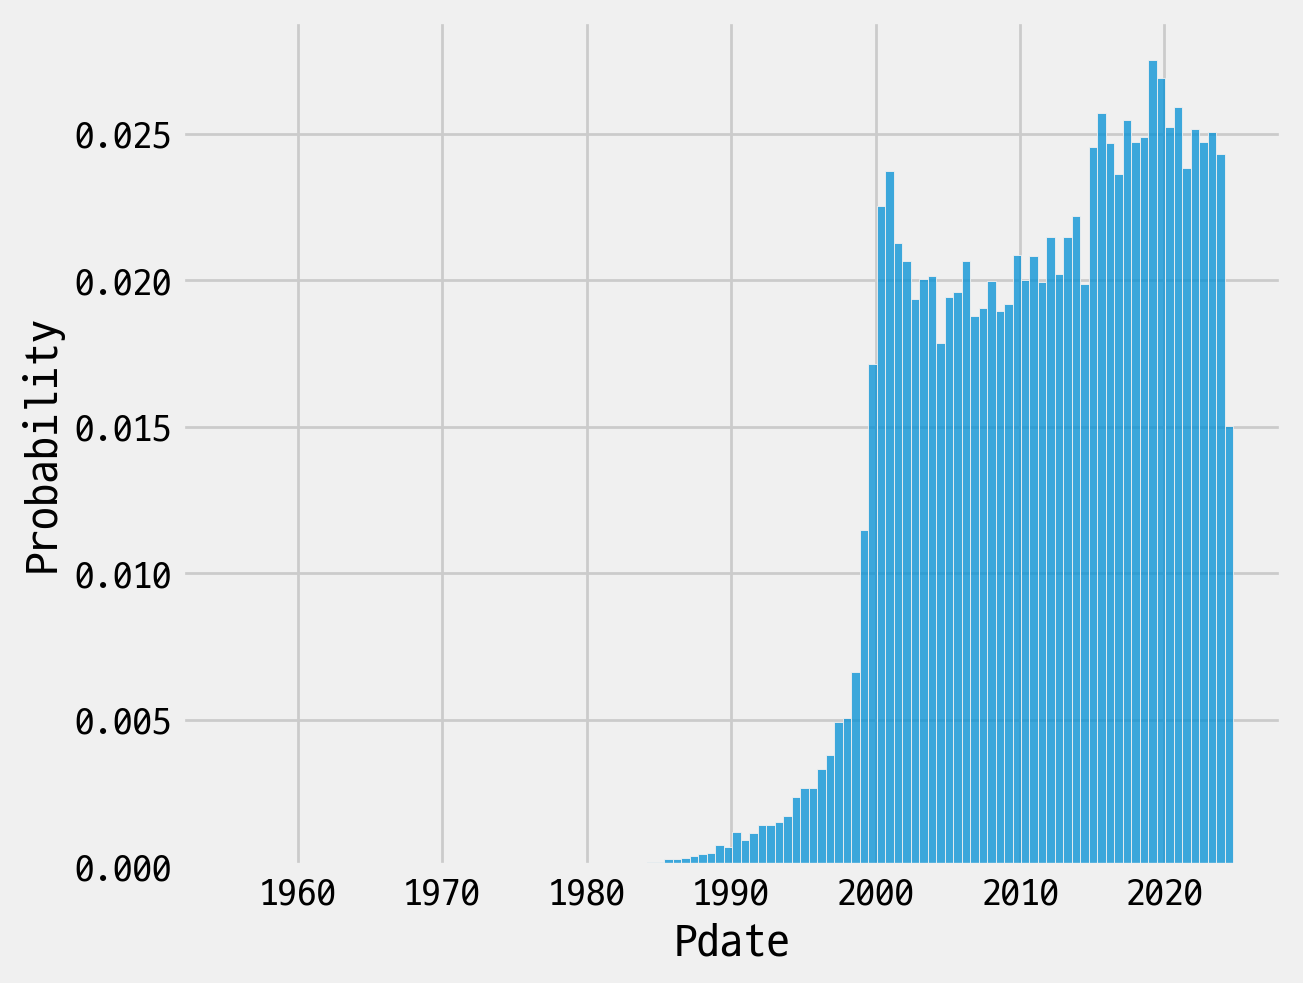

In [21]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")
sns.histplot(bk_info.Pdate,stat='probability')

In [22]:
bk_info.Pdate.describe()

count                            98835
mean     2011-09-18 09:46:49.518894848
min                1955-06-01 00:00:00
25%                2005-01-30 00:00:00
50%                2012-06-15 00:00:00
75%                2018-09-21 00:00:00
max                2024-10-04 00:00:00
Name: Pdate, dtype: object

In [23]:
bk_info['Category'].value_counts()

Category
소설/시/희곡      18378
만화           14356
수험서/자격증       6850
인문학           6086
경제경영          5972
종교/역학         5602
에세이           5064
자기계발          4412
사회과학          4300
대학교재/전문서적     3976
외국어           3574
예술/대중문화       2971
역사            2895
컴퓨터/모바일       2797
건강/취미         2489
청소년           2102
좋은부모          1990
과학            1846
요리/살림         1768
여행            1087
고전             148
달력/기타          116
어린이             41
유아              12
일본 도서            2
청소년_추천도서         1
Name: count, dtype: int64

In [24]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")
bk_info['year'] = bk_info.Pdate.dt.year
ths = 1995
cond = bk_info['year'] < ths 
print(np.mean(cond))
bk_info.loc[cond,'year'] = ths-1 

0.017402741943643447


<Axes: xlabel='year', ylabel='Count'>

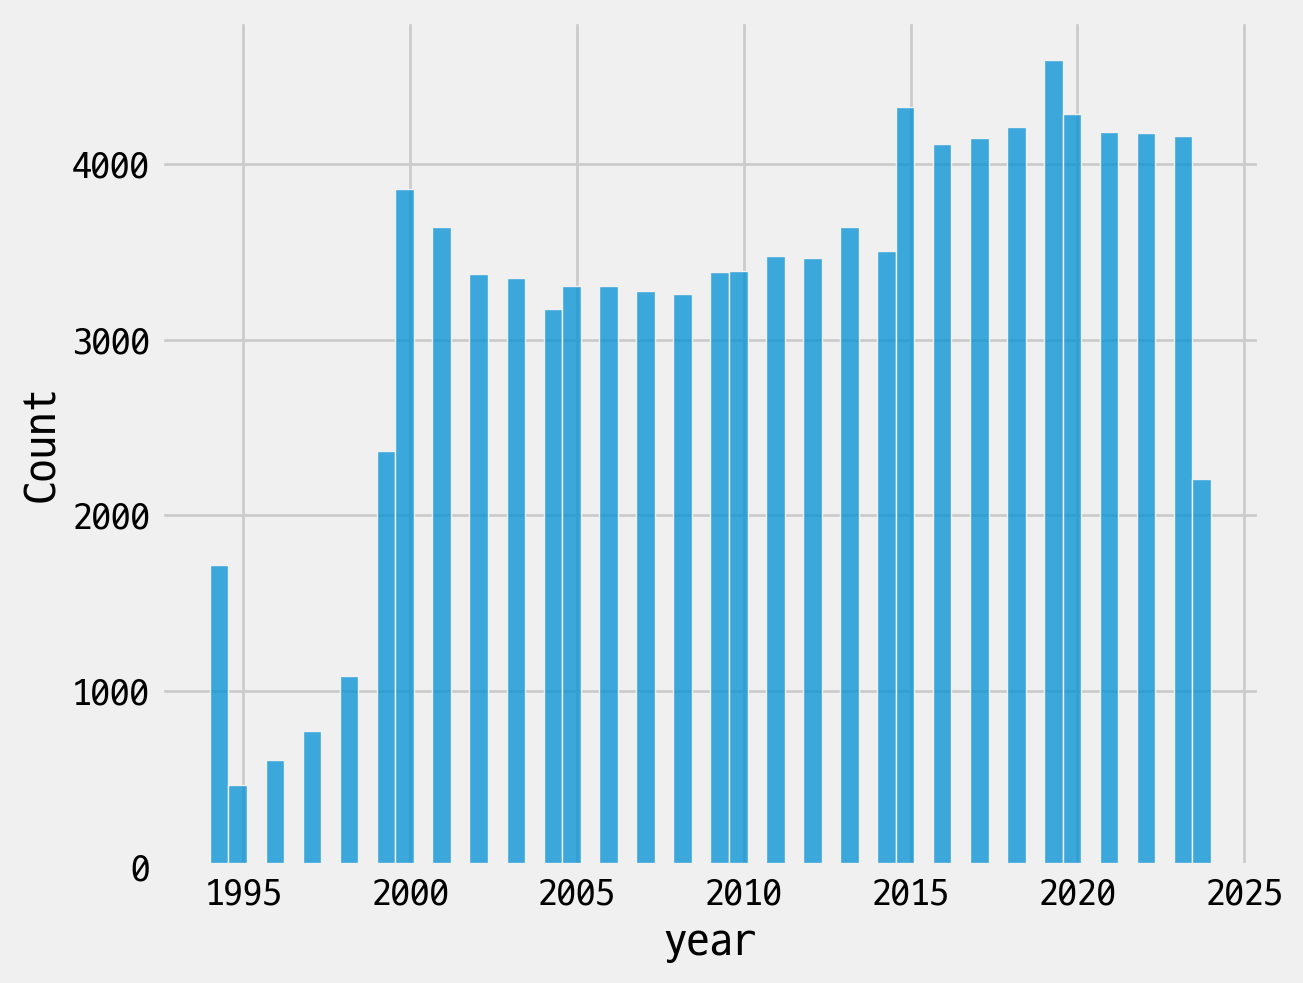

In [25]:
sns.histplot(bk_info.year)

In [118]:
fix_cate={
    '유아' : '아동/청소년',
    '청소년' : '아동/청소년',
    '청소년_추천도서' : '아동/청소년',
    '어린이' : '아동/청소년',
    '유아' : '아동/청소년',
    '일본 도서' : '외국어',
    '고전' : '인문학',
    '교육/자료' : '수험서/자격증'
}

filter_cate=['달력/기타']
df = bk_info.copy()
cond = df.Category.isin(fix_cate.keys())
df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
cond = df.Category.isin(filter_cate)
df= df[~cond]

In [27]:
cols = ['year','Category']

from itertools import product
from functools import reduce
from tqdm.auto import tqdm

def statify_df(df:pd.DataFrame,cols:list):
    col_val_lists = [np.unique(df[c]) for c in cols]
    col_vals_prod = list(product(*col_val_lists))
    rslt = dict()
    for idxs in tqdm(col_vals_prod):
        conds = [df[col] == val for col,val in zip(cols,idxs)]
        cond = reduce(lambda x,y : x & y, conds)
        rslt[idxs] = { 'data' : df[cond], 'slice' : cond}
    return rslt
        
temp = statify_df(df,cols)

  0%|          | 0/620 [00:00<?, ?it/s]

In [28]:
list(temp.keys())[0][1]
temp[(1994,'건강/취미')].keys()

dict_keys(['data', 'slice'])

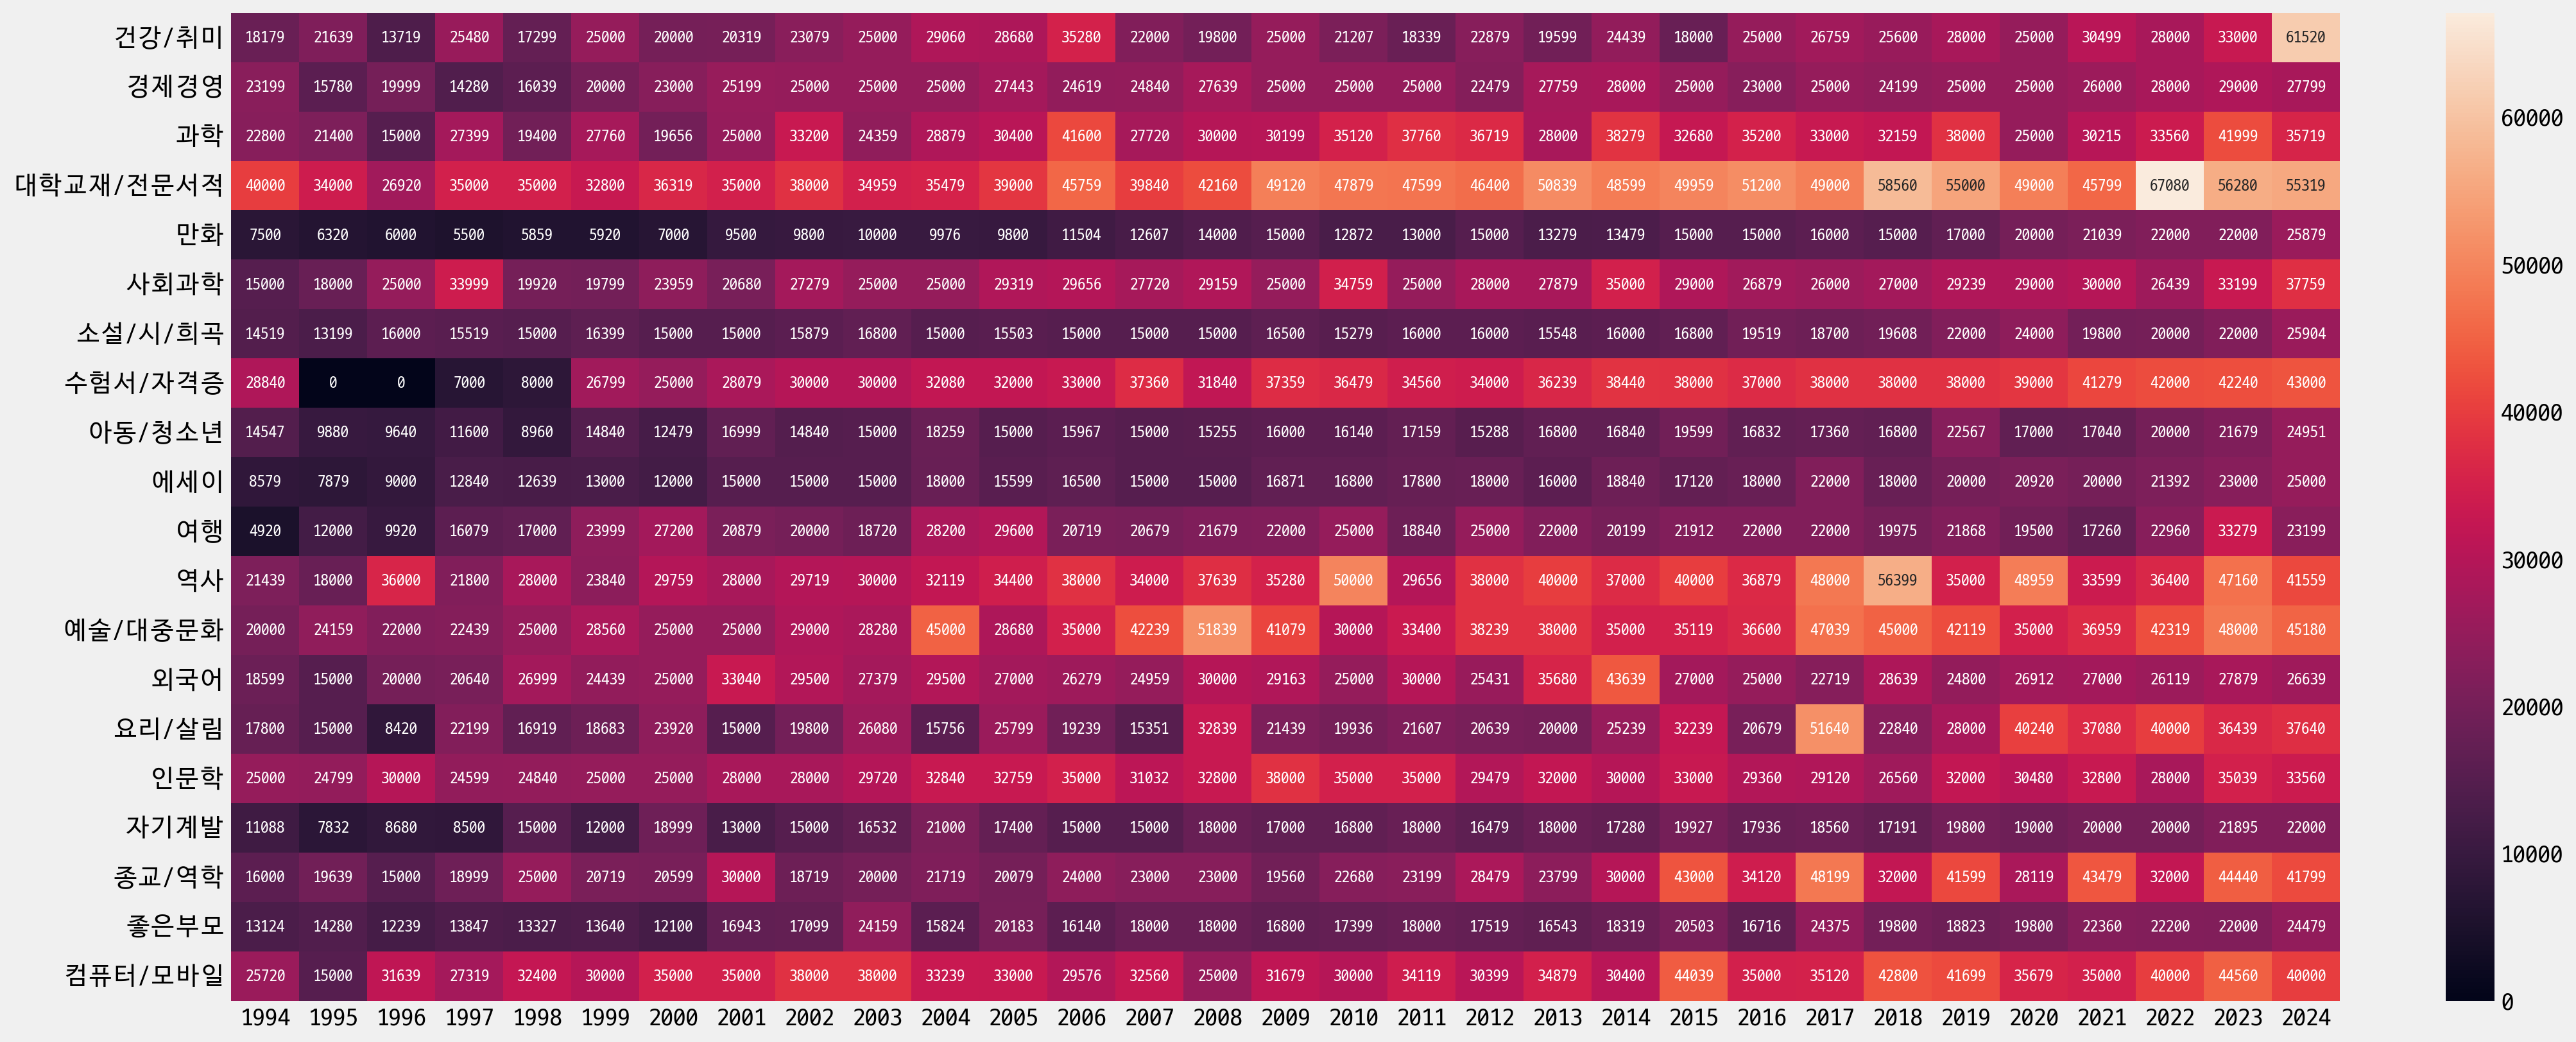

In [29]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))

q = 0.04

for key,ele in temp.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,1-q).astype(int)
    rslt[key[0]][key[1]] = content

fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

up_bnd = pd.DataFrame(rslt)

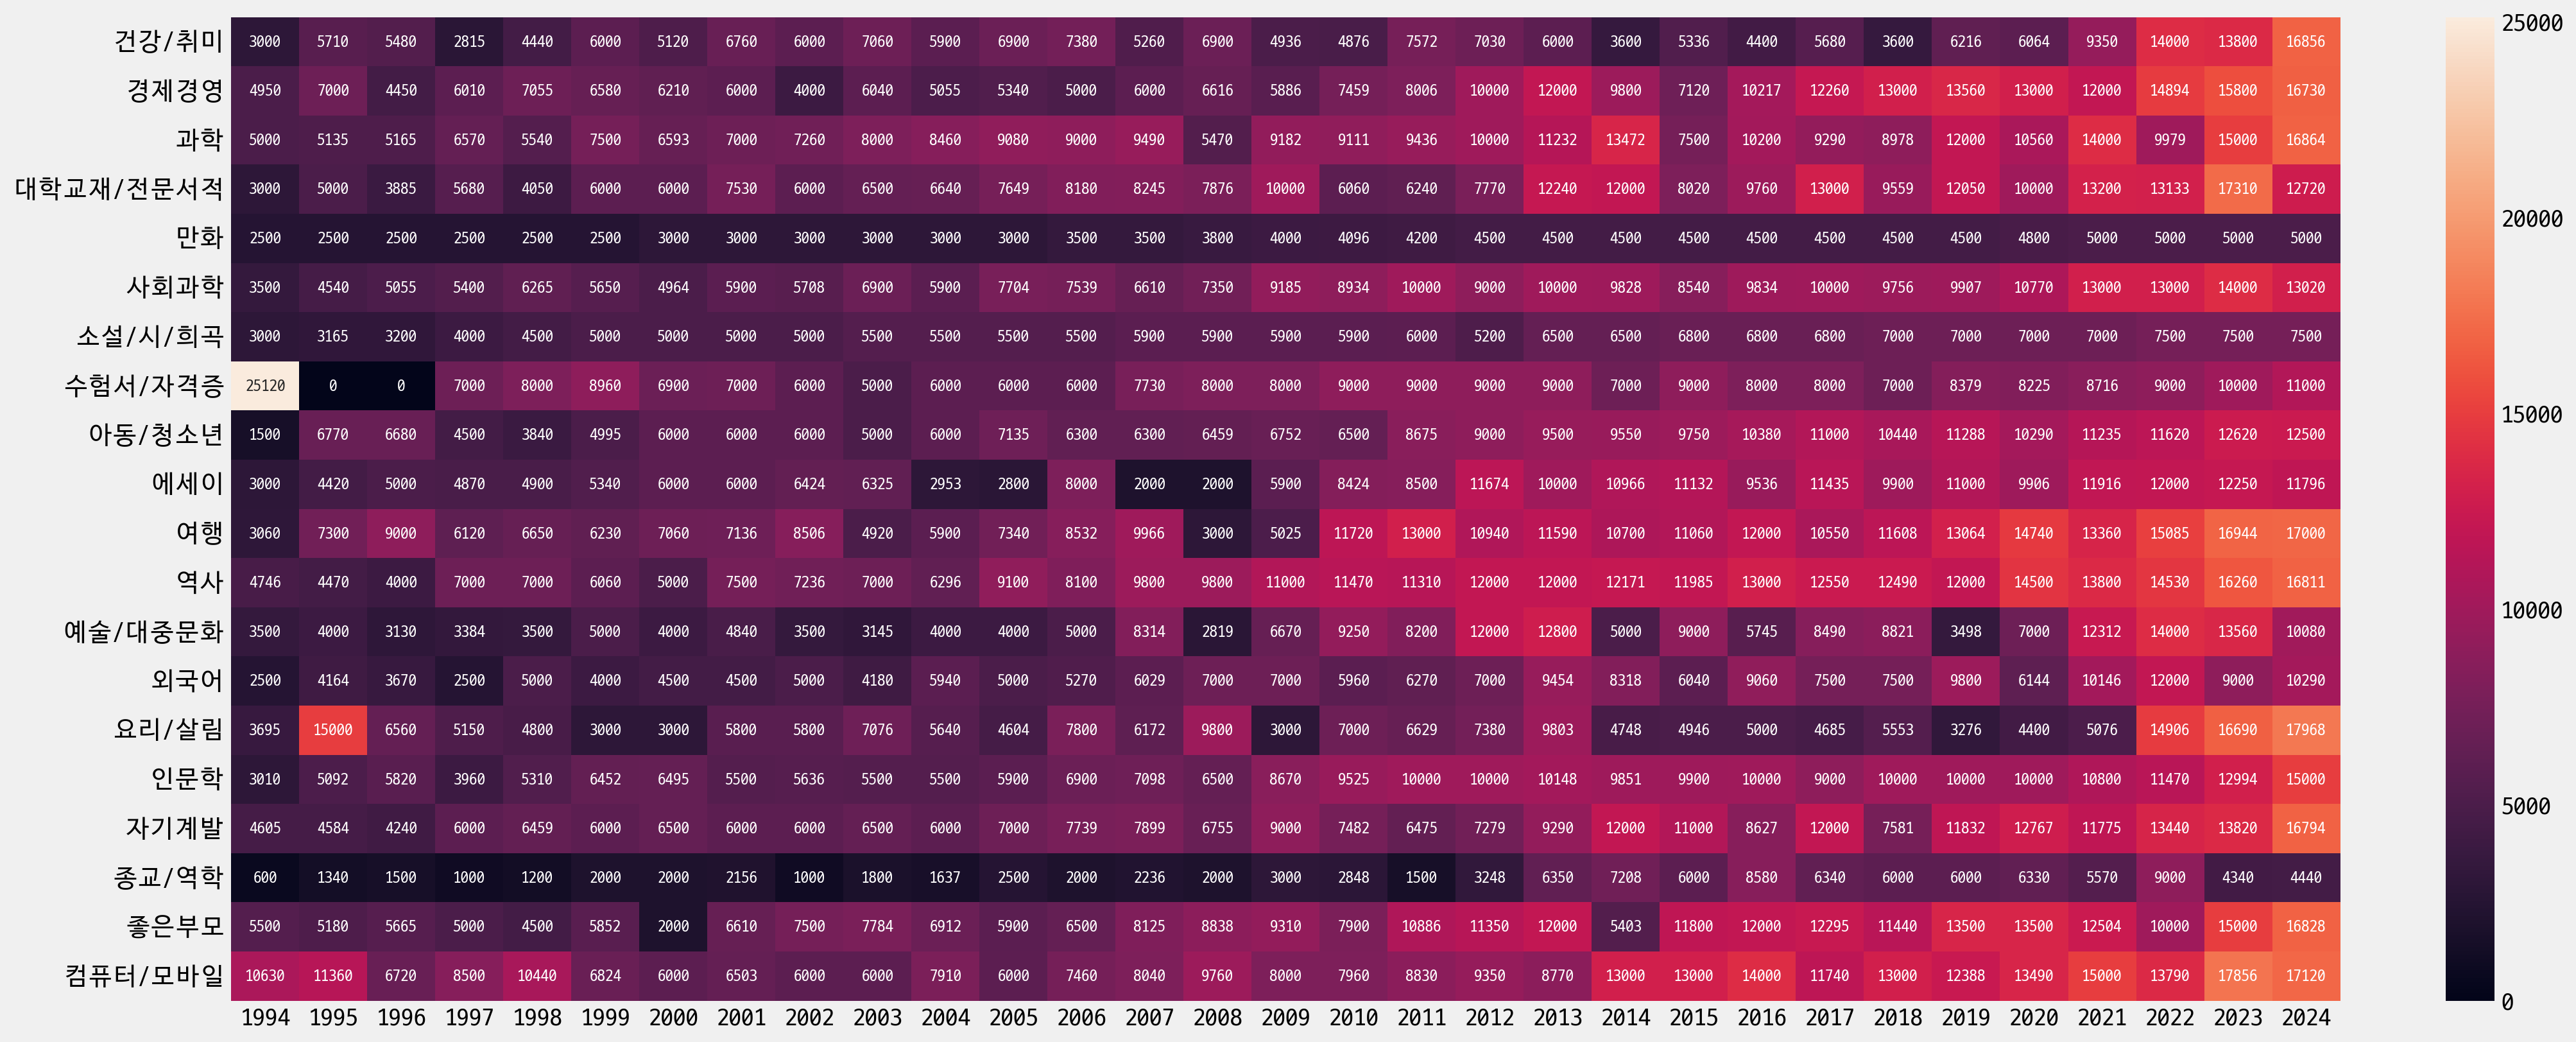

In [30]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))

q = 0.03

for key,ele in temp.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,q).astype(int)
    rslt[key[0]][key[1]] = content

fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

lw_bnd = pd.DataFrame(rslt)

<Axes: >

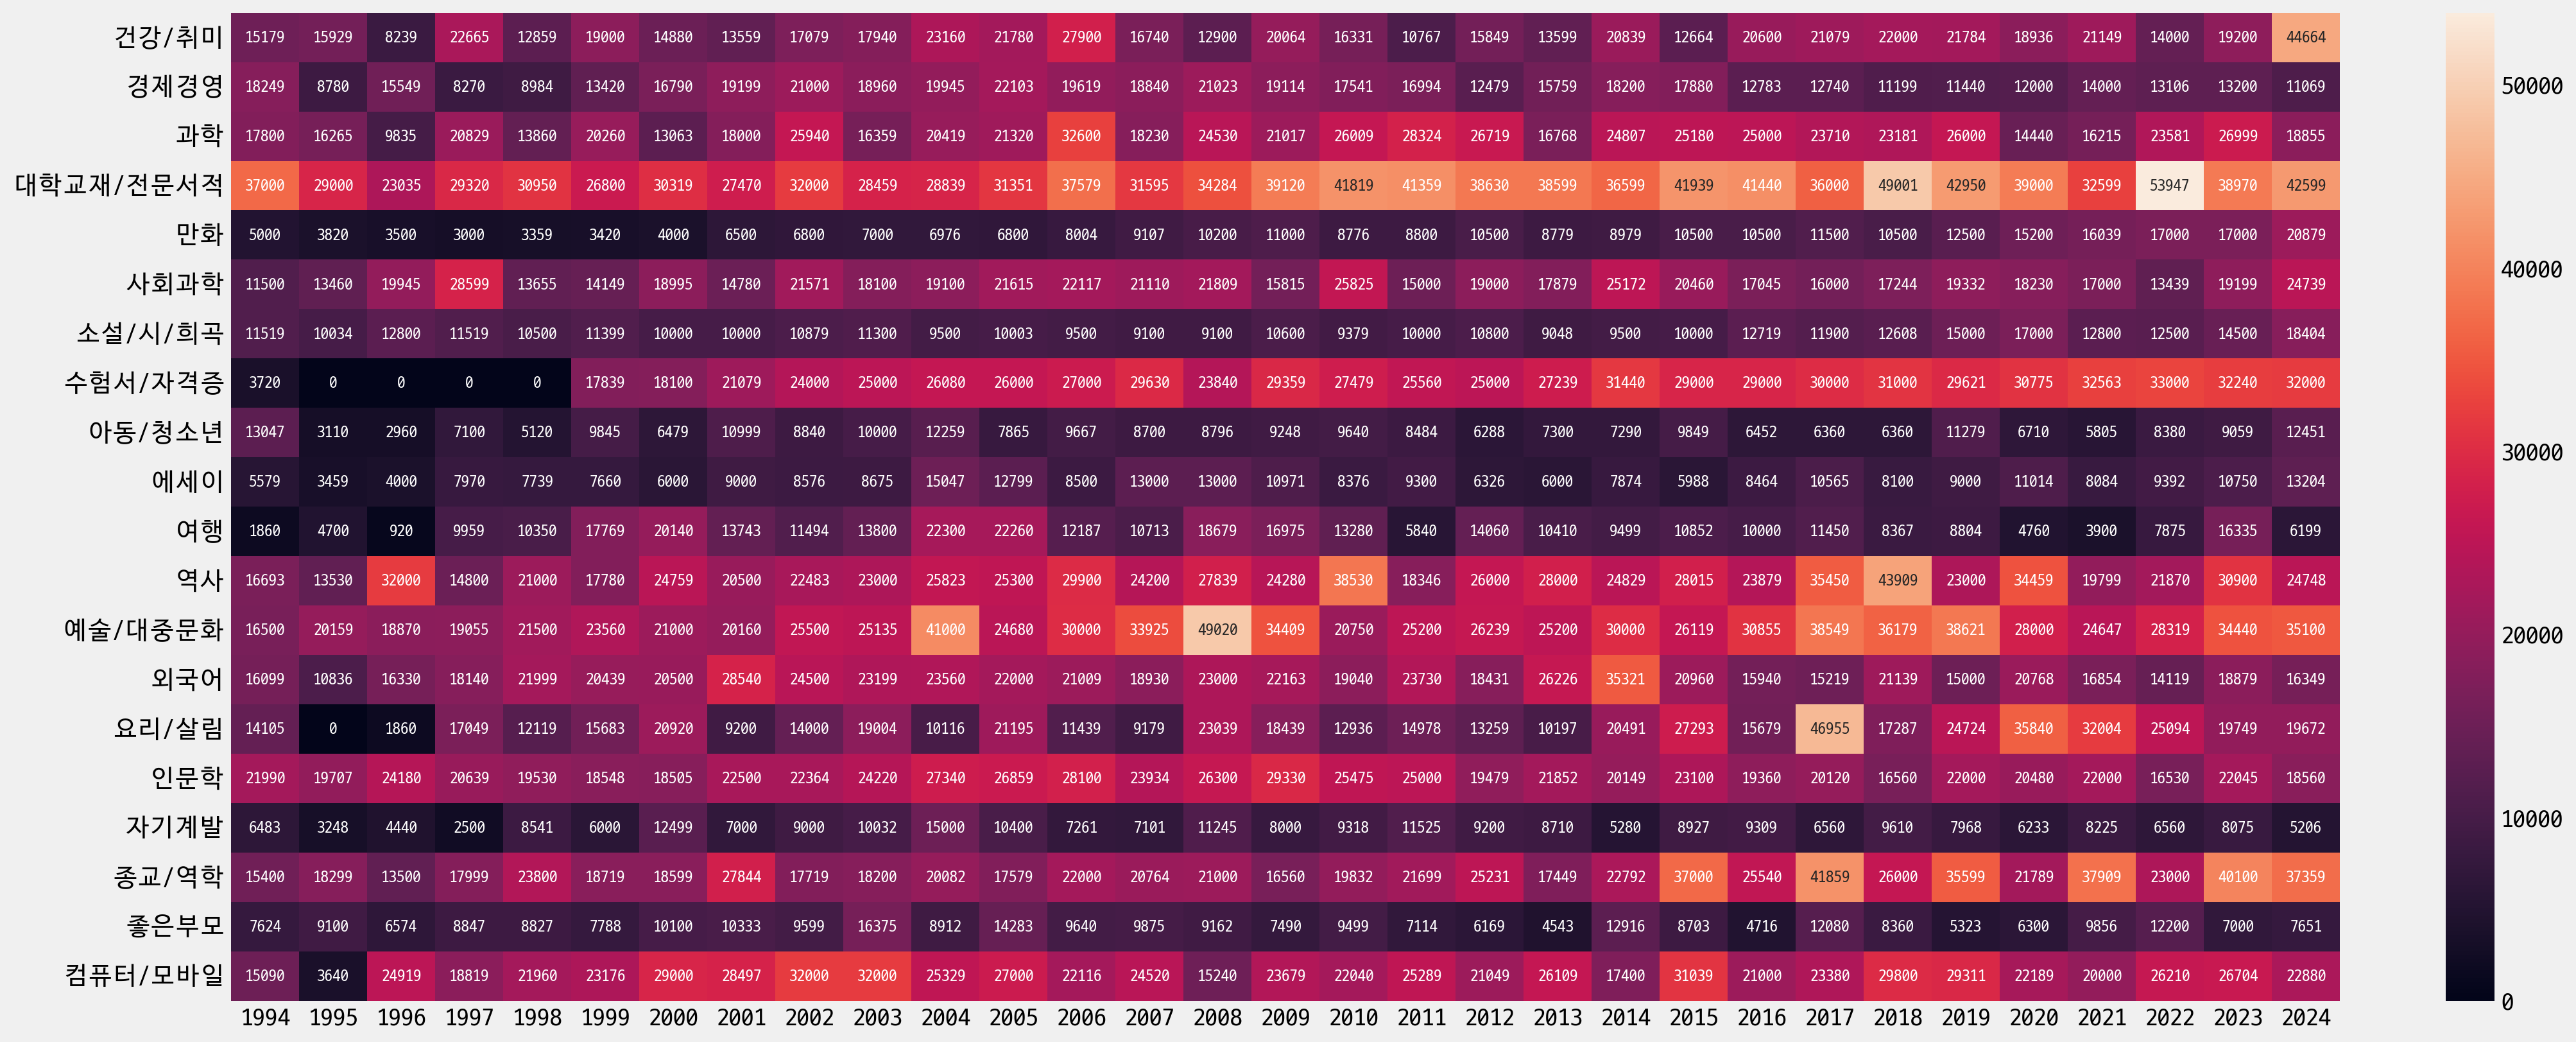

In [31]:
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(up_bnd-lw_bnd,annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

In [32]:
for y in np.unique(df.year):
    cond = df.year == y
    print(y, np.quantile(df.loc[cond,'Price'],1-0.005))

1994 45280.000000000655
1995 43350.00000000008
1996 44850.00000000014
1997 41239.99999999978
1998 45287.50000000002
1999 38000.0
2000 42190.00000000006
2001 40000.0
2002 42450.00000000028
2003 42000.0
2004 40000.0
2005 44019.99999999953
2006 49897.00000000003
2007 42719.999999999796
2008 45000.0
2009 48000.0
2010 45000.0
2011 39000.0
2012 40000.0
2013 40000.0
2014 44949.99999999982
2015 46125.0
2016 45000.0
2017 50000.0
2018 49000.0
2019 53000.0
2020 49915.999999999985
2021 49000.0
2022 52359.99999999967
2023 55000.0
2024 54939.9999999996


In [33]:
for y in np.unique(df.year):
    cond = df.year == y
    print(y, np.quantile(df.loc[cond,'Price'],0.005))

1994 600.0
1995 1330.0
1996 1500.0
1997 1000.0
1998 1200.0
1999 2000.0
2000 2500.0
2001 2500.0
2002 1500.0
2003 2000.0
2004 2000.0
2005 2500.0
2006 2000.0
2007 2056.0
2008 2000.0
2009 3000.0
2010 3000.0
2011 3000.0
2012 4200.0
2013 4500.0
2014 4010.000000000001
2015 4000.0
2016 3282.5000000000005
2017 3000.0
2018 4000.0
2019 4000.0
2020 4000.0
2021 4800.0
2022 5000.0
2023 5000.0
2024 5000.0


In [34]:
#bnd_diff = up_bnd-lw_bnd

ths_up = 45000 
ths_lw = 3000
#ths_diff = 10000

slice_dict = dict() 
ths_dict= dict() 

for key,ele in temp.items():
    up, low = up_bnd.loc[key[1],key[0]],lw_bnd.loc[key[1],key[0]]
    #if up - low < ths_diff : 
    ths_dict[key]={
        'up' : max(up,ths_up),
        'lw' : min(low,ths_lw),
    }
    
for key,ele in temp.items():
    data = ele['data']
    cond = (data['Price'] <= ths_dict[key]['up']) & (data['Price']>= ths_dict[key]['lw'])
    slice_dict[key] = data[cond]

In [35]:
len(pd.concat(list(slice_dict.values())))/len(df)

0.9918151520983802

<Axes: >

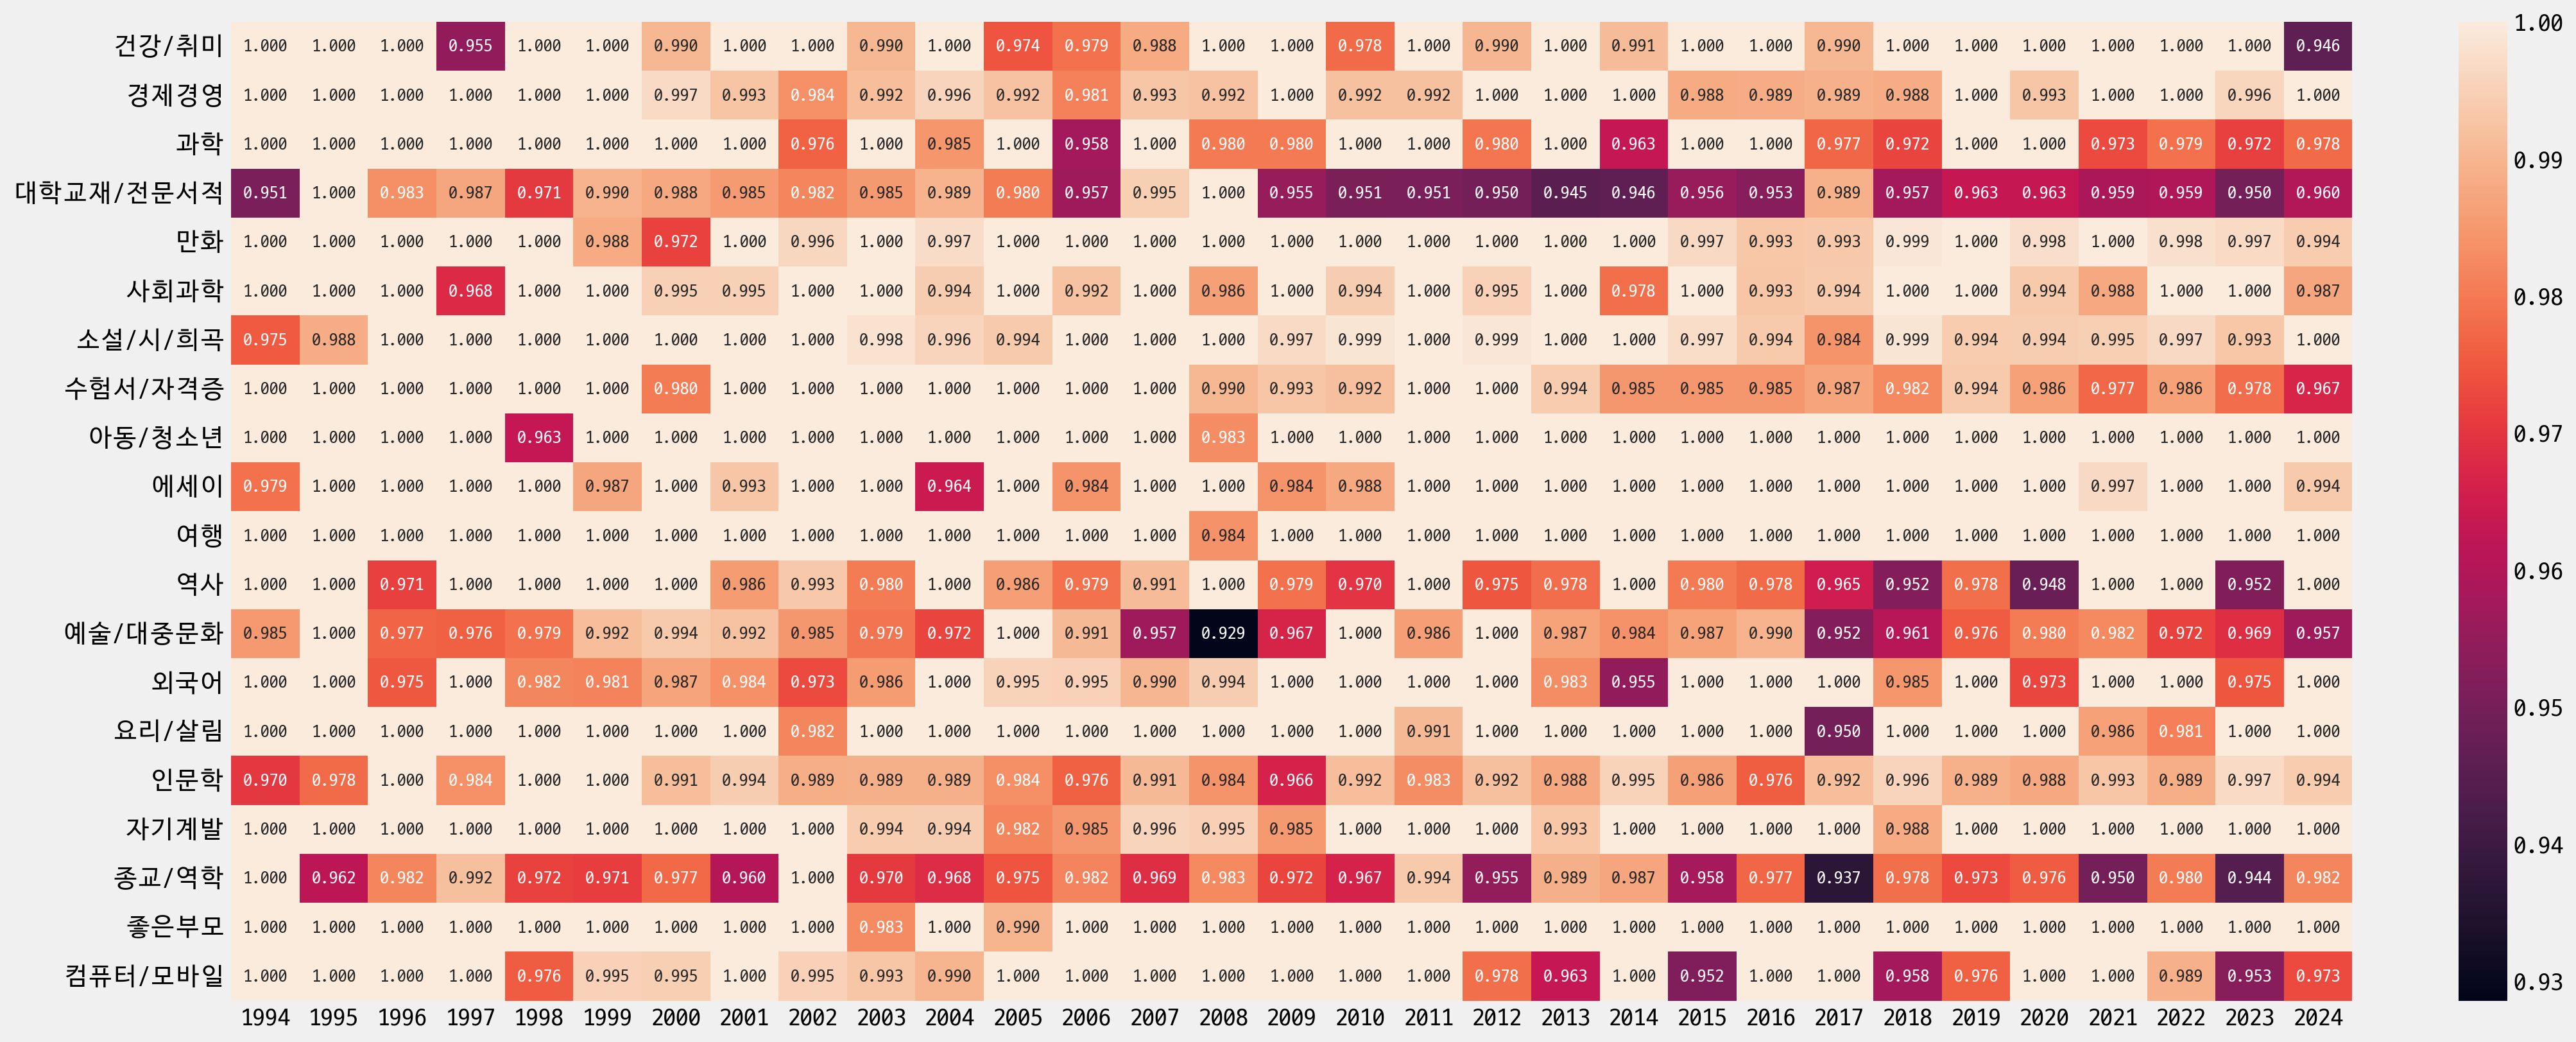

In [39]:
rslt = defaultdict(lambda : defaultdict(int))
for key,ele in temp.items():
    ratio = len(slice_dict[key])/len(ele['data']) if len(ele['data']) >0 else 1
    rslt[key[0]][key[1]] = ratio
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':10},fmt='.3f',ax=ax)

<Axes: >

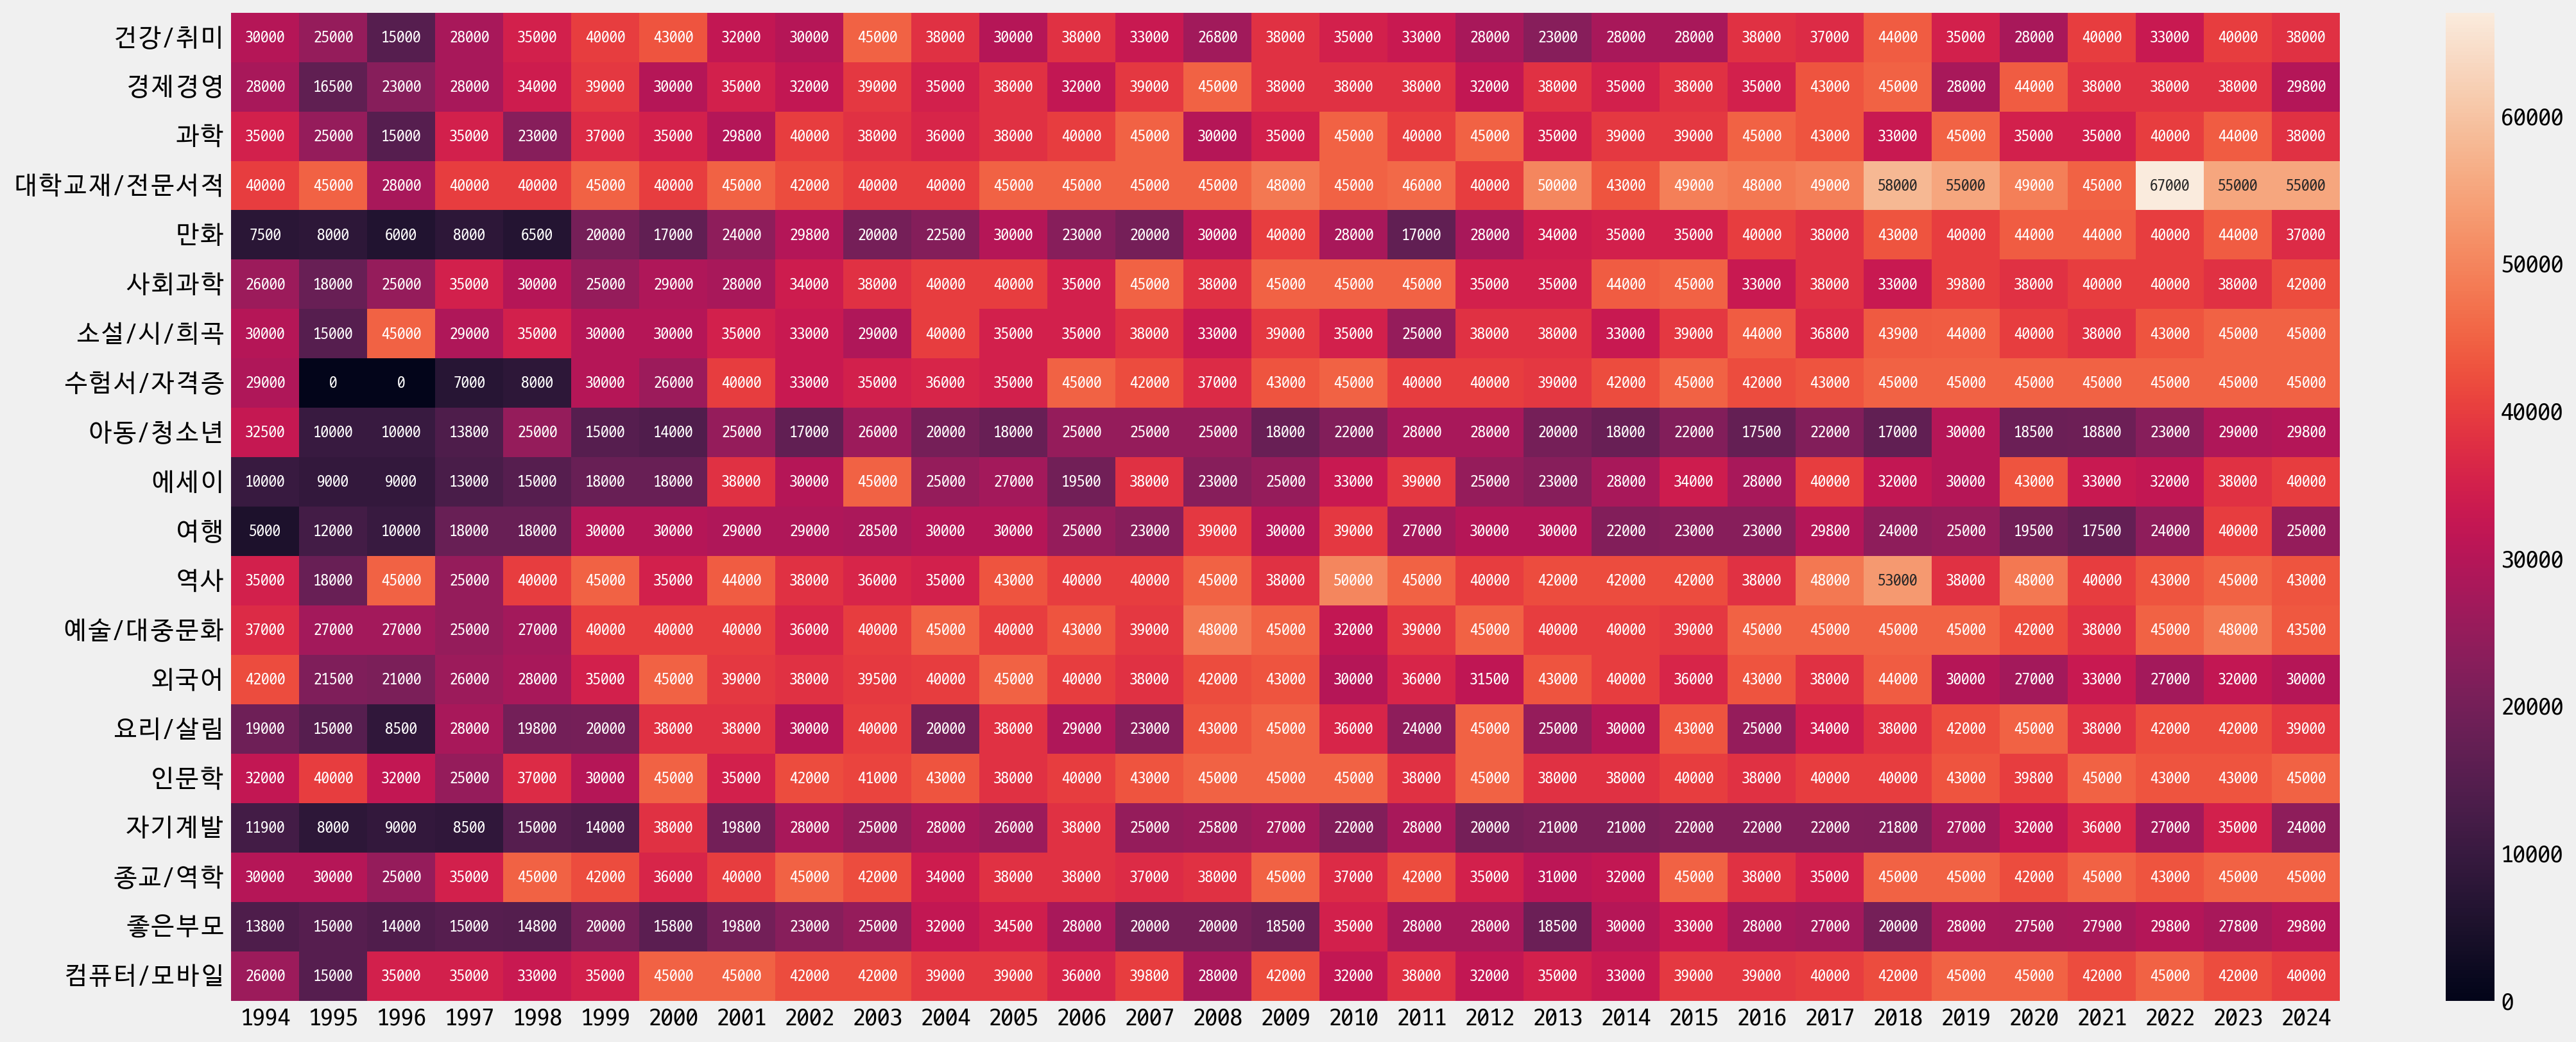

In [43]:
rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    rslt[key[0]][key[1]] = max(ele['Price']) if len(ele) > 0 else 0
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

<Axes: >

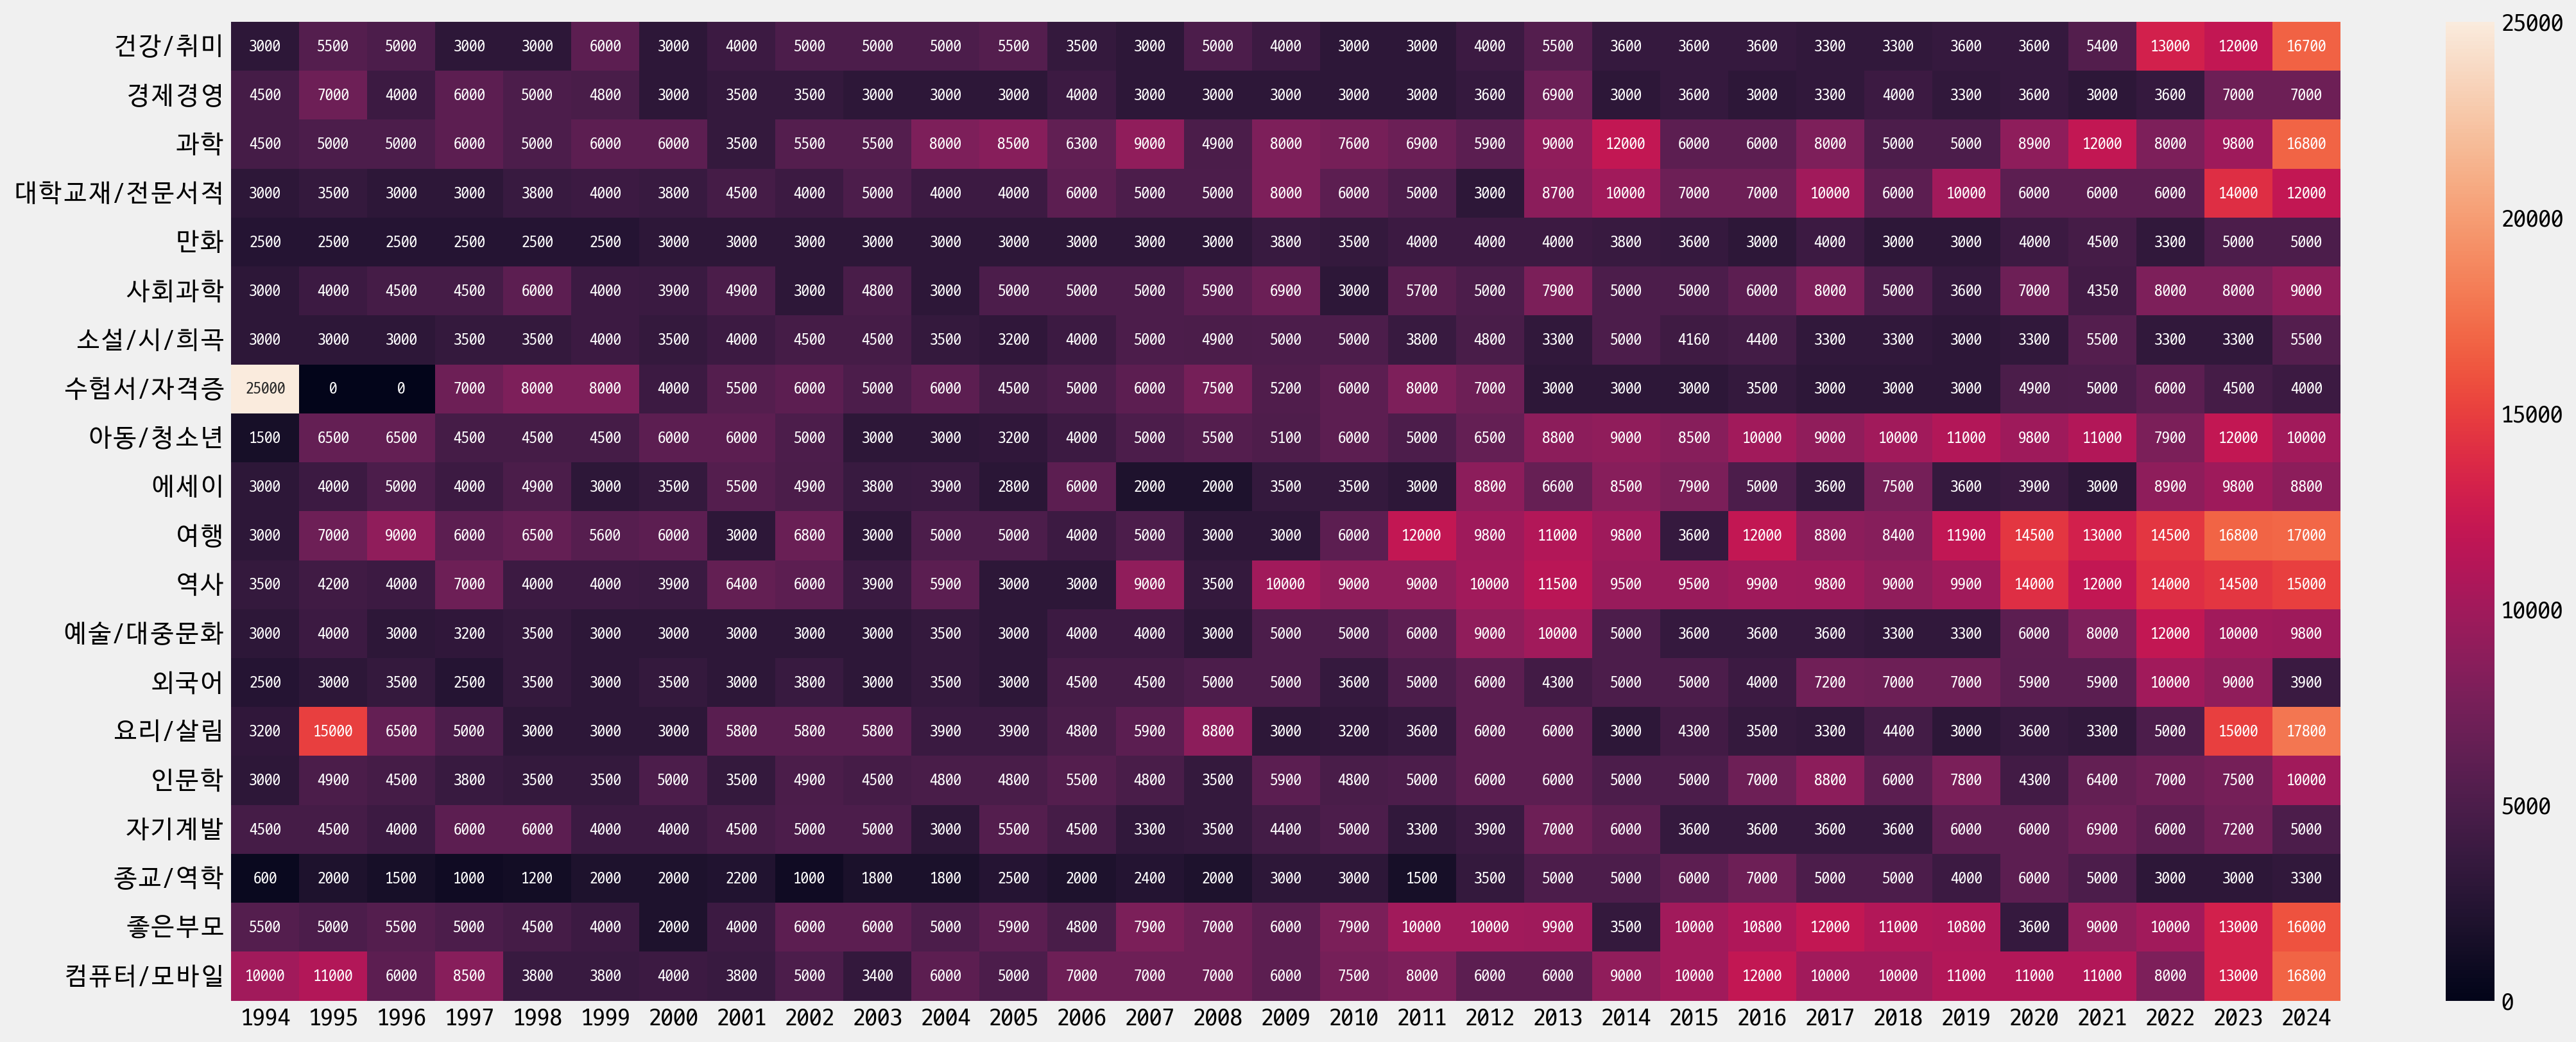

In [44]:
rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    rslt[key[0]][key[1]] = min(ele['Price']) if len(ele) > 0 else 0
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

<Axes: >

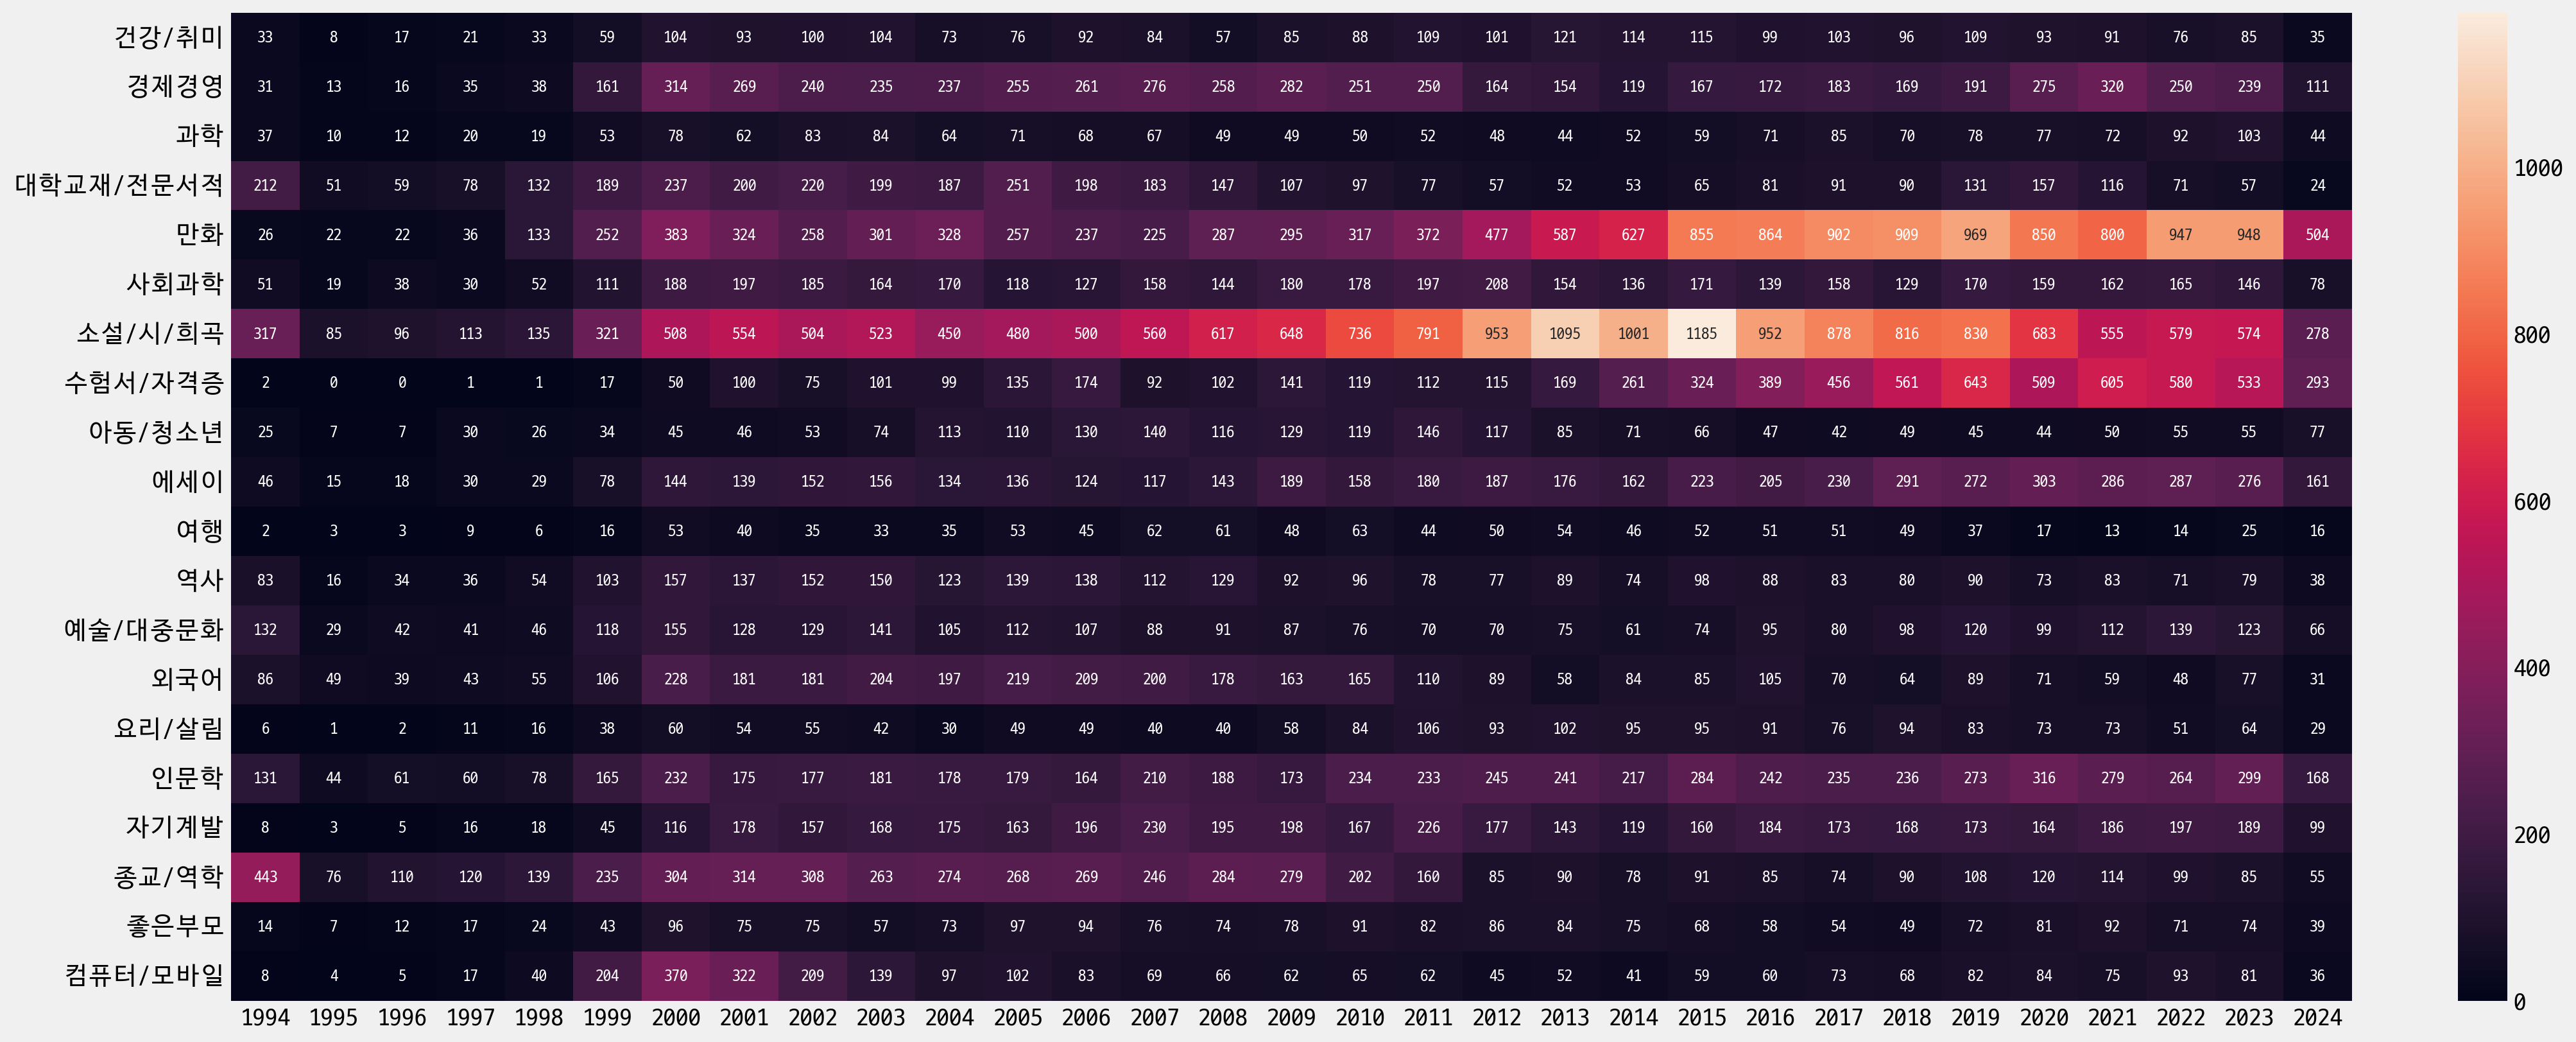

In [45]:
rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    rslt[key[0]][key[1]] = len(ele)
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

<Axes: >

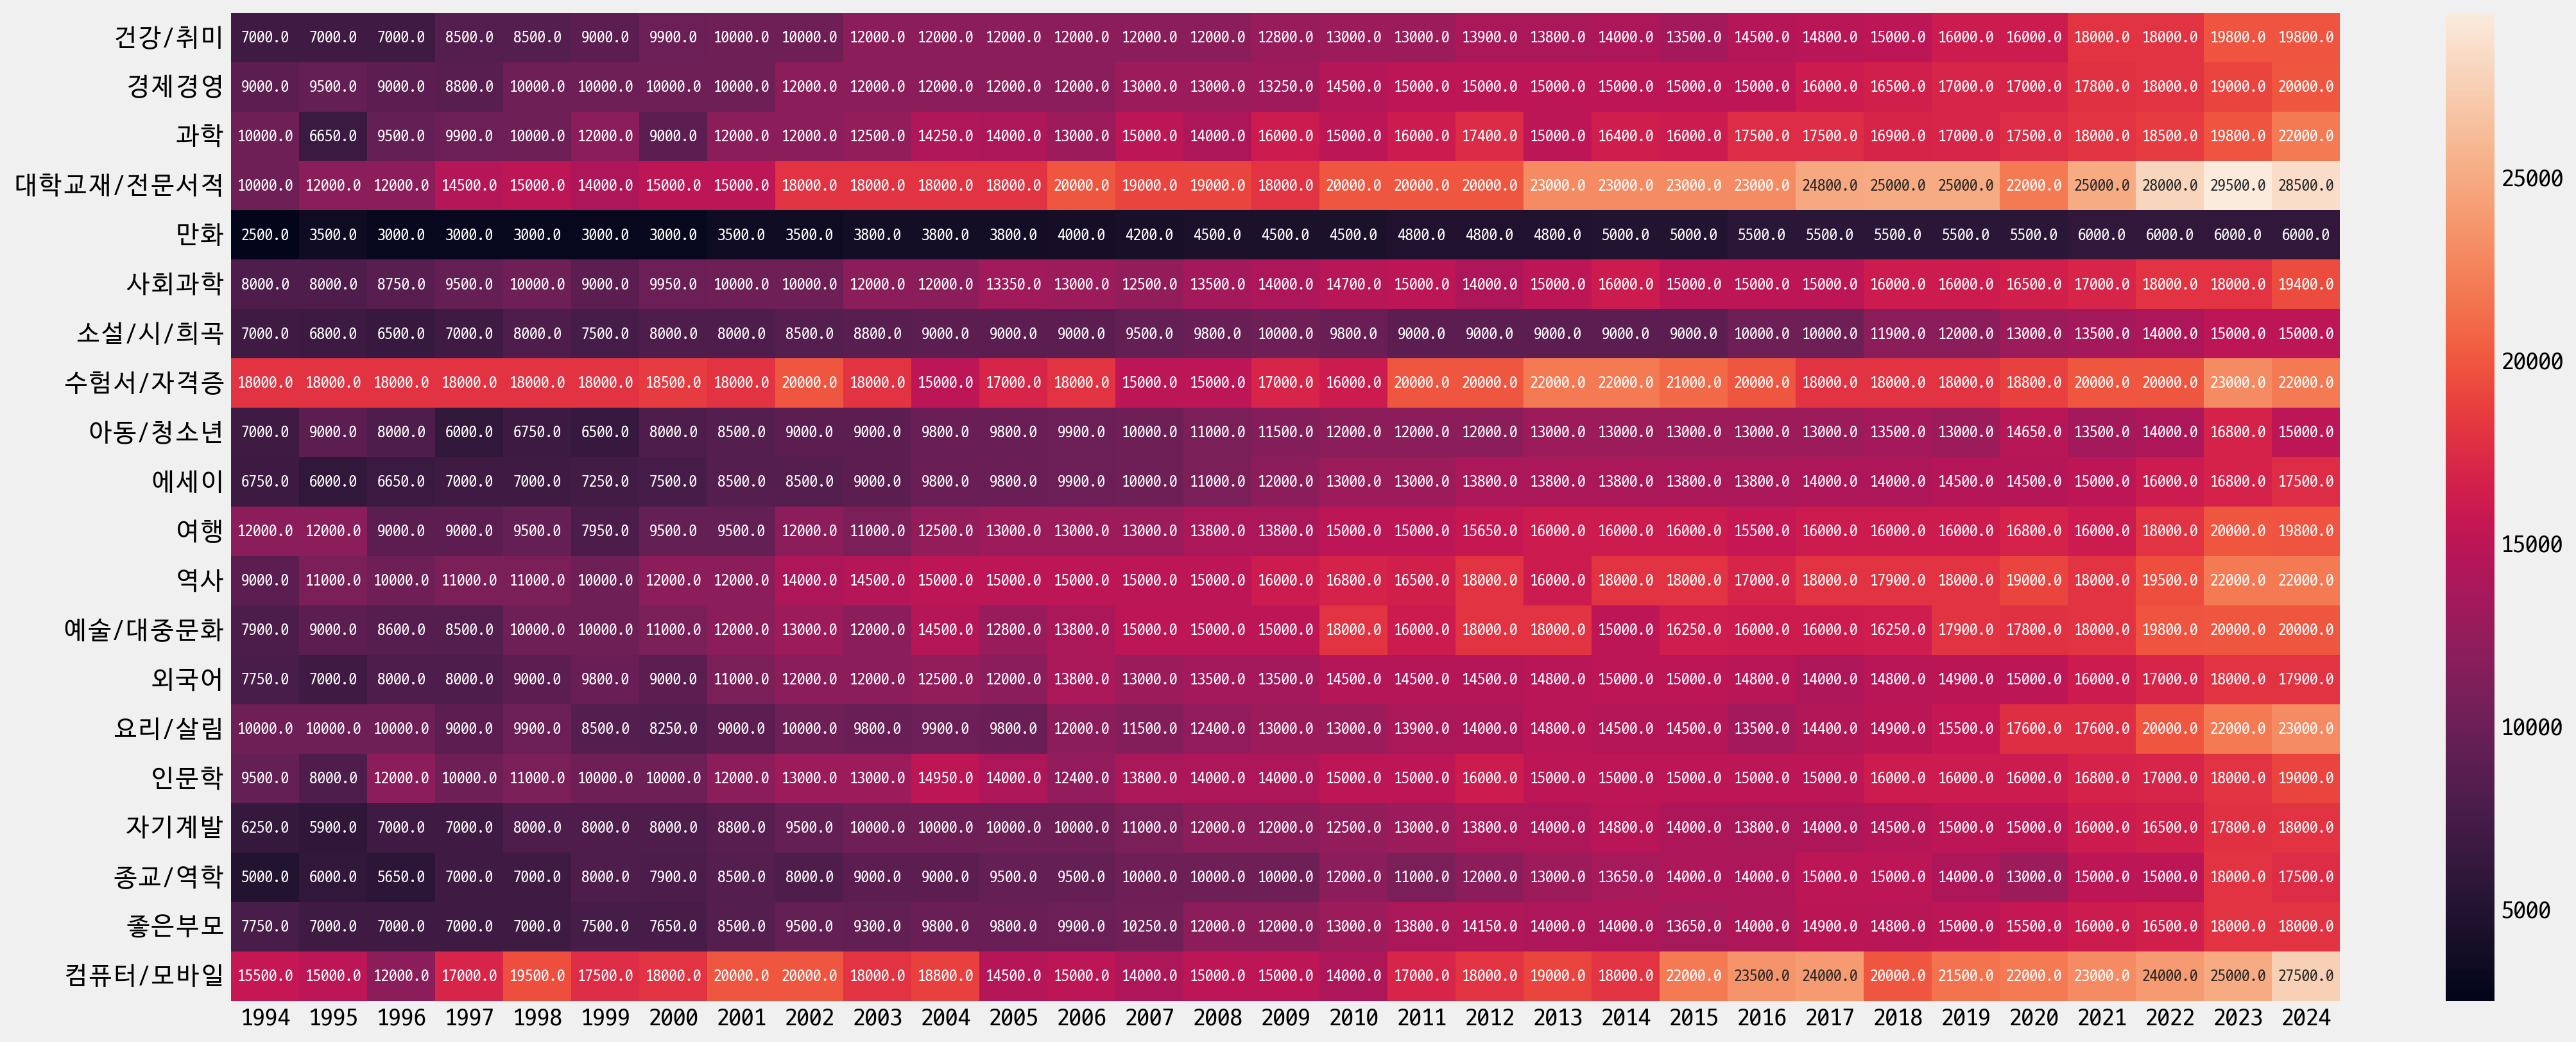

In [61]:
answer_sheet = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    answer_sheet[key[0]][key[1]] = np.median(ele['Price']) if len(ele)> 2 else np.nan
    
    
fig, ax = plt.subplots(figsize=(20,8))

answer_sheet = pd.DataFrame(answer_sheet)
answer_sheet = answer_sheet.ffill(axis=1)
answer_sheet = answer_sheet.bfill(axis=1)

sns.heatmap(answer_sheet,annot=True,annot_kws={'fontsize':9},fmt='.1f',ax=ax)

In [119]:
X_vld = data_dict['vld']['X']
y_vld = data_dict['vld']['y']
df = X_vld.copy()
cond = df.Category.isin(fix_cate.keys())
df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
cond = df.Category.isin(filter_cate)
X_vld= df[~cond]
y_vld= y_vld[~cond]


X_vld.Pdate = pd.to_datetime(X_vld.Pdate,format="%Y%m%d")
X_vld['year'] = X_vld.Pdate.dt.year
ths = 1995
cond = X_vld['year'] < ths 
print(np.mean(cond))
X_vld.loc[cond,'year'] = ths-1 


0.018315166740953848


/tmp/ipykernel_56252/3383949336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_vld.Pdate = pd.to_datetime(X_vld.Pdate,format="%Y%m%d")
/tmp/ipykernel_56252/3383949336.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_vld['year'] = X_vld.Pdate.dt.year


In [122]:
answer_sheet.to_dict()

cheat=dict()
for k1,ele in answer_sheet.to_dict().items():
    for k2,val in ele.items():
        cheat[f'{k1}|{k2}']=val

In [123]:
def cheat_sheet(X,sheet,cols):
    X = X.astype(str)
    X_keys = X[cols].apply(lambda x : '|'.join(x.values),axis=1)
    return X_keys.map(sheet)

y_prd = cheat_sheet(X_vld,cheat,cols)

In [124]:
y_prd.describe(), y_vld.describe()

(count    24679.000000
 mean     12244.165080
 std       4779.095523
 min       2500.000000
 25%       9000.000000
 50%      12000.000000
 75%      15000.000000
 max      29500.000000
 dtype: float64,
 count     24679.000000
 mean      13631.348515
 std        8389.908067
 min         500.000000
 25%        8000.000000
 50%       12500.000000
 75%       16500.000000
 max      285000.000000
 Name: RglPrice, dtype: float64)

In [125]:
mape(y_vld,y_prd), r2_score(y_vld,y_prd), np.power(mse(y_vld,y_prd),0.5)

(0.2907998214370578, 0.31511495877842766, 6943.161119000866)

In [126]:
X_tst = data_dict['tst']['X']
y_tst = data_dict['tst']['y']
df = X_tst.copy()
cond = df.Category.isin(fix_cate.keys())
df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
cond = df.Category.isin(filter_cate)
X_tst= df[~cond]
y_tst= y_tst[~cond]


X_tst.Pdate = pd.to_datetime(X_tst.Pdate,format="%Y%m%d")
X_tst['year'] = X_tst.Pdate.dt.year
ths = 1995
cond = X_tst['year'] < ths 
print(np.mean(cond))
X_tst.loc[cond,'year'] = ths-1 

y_prd = cheat_sheet(X_tst,cheat,cols)

0.018183586153247763


/tmp/ipykernel_56252/4294081330.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_tst.Pdate = pd.to_datetime(X_tst.Pdate,format="%Y%m%d")
/tmp/ipykernel_56252/4294081330.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_tst['year'] = X_tst.Pdate.dt.year


In [127]:
np.sum(y_tst.isna()), np.sum(y_prd.isna())

X_tst[y_prd.isna()]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,year


In [128]:
mape(y_tst,y_prd), r2_score(y_tst,y_prd), np.power(mse(y_tst,y_prd),0.5)

(0.29036214925184023, 0.3432051073631063, 6481.729605943042)

In [21]:
temp = pd.crosstab(bk_info['year'],bk_info['Category']).T
temp

year,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Category,,,,,,,,,,,,,,,,,,,,,
건강/취미,33,8,17,22,33,59,105,93,100,105,...,115,99,104,96,109,93,91,76,85,37
경제경영,31,13,16,35,38,161,315,271,244,237,...,169,174,185,171,191,277,320,250,240,111
고전,10,2,2,6,5,12,21,14,10,14,...,0,0,0,0,0,0,0,0,0,0
과학,37,10,12,20,19,53,78,62,85,84,...,59,71,87,72,78,77,74,94,106,45
달력/기타,1,0,0,0,0,0,3,29,2,5,...,1,1,2,1,1,0,0,0,0,0
대학교재/전문서적,223,51,60,79,136,191,240,203,224,202,...,68,85,92,94,136,163,121,74,60,25
만화,26,22,22,36,133,255,394,324,259,301,...,858,870,908,910,969,852,800,949,951,507
사회과학,51,19,38,31,52,111,189,198,185,164,...,171,140,159,129,170,160,164,165,146,79
소설/시/희곡,325,86,96,113,135,321,508,554,504,524,...,1188,958,892,817,835,687,558,581,578,278


In [22]:
bk_info[bk_info['Category']=='유아']

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,Price,year
154259,판판판 포피포피 판판판,NaN,제레미 모로,웅진주니어,True,2024-06-17,8285,유아,15000,2024
154408,무례한 친구가 생겼어요,NaN,크리스티나 퍼니발,리틀포레스트,True,2024-02-21,40029,유아,16700,2024
154293,디즈니.픽사 인사이드 아웃 2,NaN,백정선,Oh!북스,True,2024-06-15,8580,유아,12000,2024
154361,당신을 측정해 드립니다,NaN,권정민,사계절,False,2024-05-30,10095,유아,16800,2024
154271,감정 호텔,NaN,리디아 브란코비치,책읽는곰,True,2024-02-23,27998,유아,15000,2024
154304,이파라파냐무냐무,NaN,이지은,사계절,False,2020-06-10,23096,유아,16500,2020
154428,달샤베트,NaN,백희나,Storybowl(스토리보울),False,2024-06-10,5505,유아,15000,2024
154378,"숀 탠, 한 예술가의 스케치",NaN,숀 탠,풀빛,True,2024-06-14,8750,유아,25000,2024
154377,알사탕,NaN,백희나,Storybowl(스토리보울),False,2024-03-21,14760,유아,15000,2024
154382,이순신을 찾아라,NaN,김진,천개의바람,True,2024-06-25,3120,유아,15000,2024


In [23]:
bk_info[bk_info['Category']=='일본 도서']

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,Price,year
17463,신일본어기초 2,NaN,해외기술자연수협회,문진미디어(문진당),False,1993-11-01,40,일본 도서,6000,1994
7665,신일본어기초 2의 표준문제집,NaN,문진미디어 편집부,문진미디어(문진당),False,1994-05-01,28,일본 도서,4000,1994


In [24]:
bk_info[bk_info['Category']=='달력/기타'].iloc[50:90]

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,Price,year
15071,클레 캘린더,NaN,독일teNeues 편집부,독일teNeues,False,2001-11-01,51,달력/기타,13000,2001
15029,샤갈 캘린더,NaN,독일teNeues 편집부,독일teNeues,False,2001-11-01,58,달력/기타,7000,2001
58219,우먼센스 가계부 2010,NaN,서울문화사 편집부,서울문화사(잡지),False,2010-01-01,166,달력/기타,9000,2010
69535,2012 가계북,NaN,그리고책 편집부,이밥차(그리고책),False,2011-11-04,132,달력/기타,15000,2011
63148,2011 이철수 판화 달력,(탁상용),이철수,끄레디자인(creedesign),False,2010-11-19,256,달력/기타,9500,2010
55039,"내 생애 최고의 멘토, 조지 브라운 - 오디오 CD 1장",[CD],이영권,석세스티브이(북리슨),False,2008-01-28,314,달력/기타,6000,2008
51993,알뜰주부들을 위한 가계부 2010,NaN,윤미디어 편집부,윤미디어,False,2006-11-18,21,달력/기타,7000,2006
47861,Teachme! Study Planner,NaN,한석원.김찬휘.강필,랜덤하우스코리아,False,2007-01-08,706,달력/기타,10000,2007
80543,2014 가계북,NaN,그리고책 편집부,이밥차(그리고책),False,2013-11-05,688,달력/기타,15000,2013
60685,당신도 최고의 네트워커가 될 수 있다 - 테이프 1개,NaN,우종철,아름다운사회,False,2009-01-01,34,달력/기타,3500,2009


In [25]:
temp.loc[['청소년','유아','어린이','청소년_추천도서','일본 도서']].T

Category,청소년,유아,어린이,청소년_추천도서,일본 도서
year,,,,,
1994,25,0,0,0,2
1995,7,0,0,0,0
1996,7,0,0,0,0
1997,30,0,0,0,0
1998,27,0,0,0,0
1999,34,0,0,0,0
2000,45,0,0,0,0
2001,46,0,0,0,0
2002,53,0,0,0,0


In [26]:
temp.loc[['고전','인문학','소설/시/희곡','사회과학']].T

Category,고전,인문학,소설/시/희곡,사회과학
year,,,,
1994,10,125,325,51
1995,2,43,86,19
1996,2,59,96,38
1997,6,55,113,31
1998,5,73,135,52
1999,12,153,321,111
2000,21,213,508,189
2001,14,162,554,198
2002,10,169,504,185


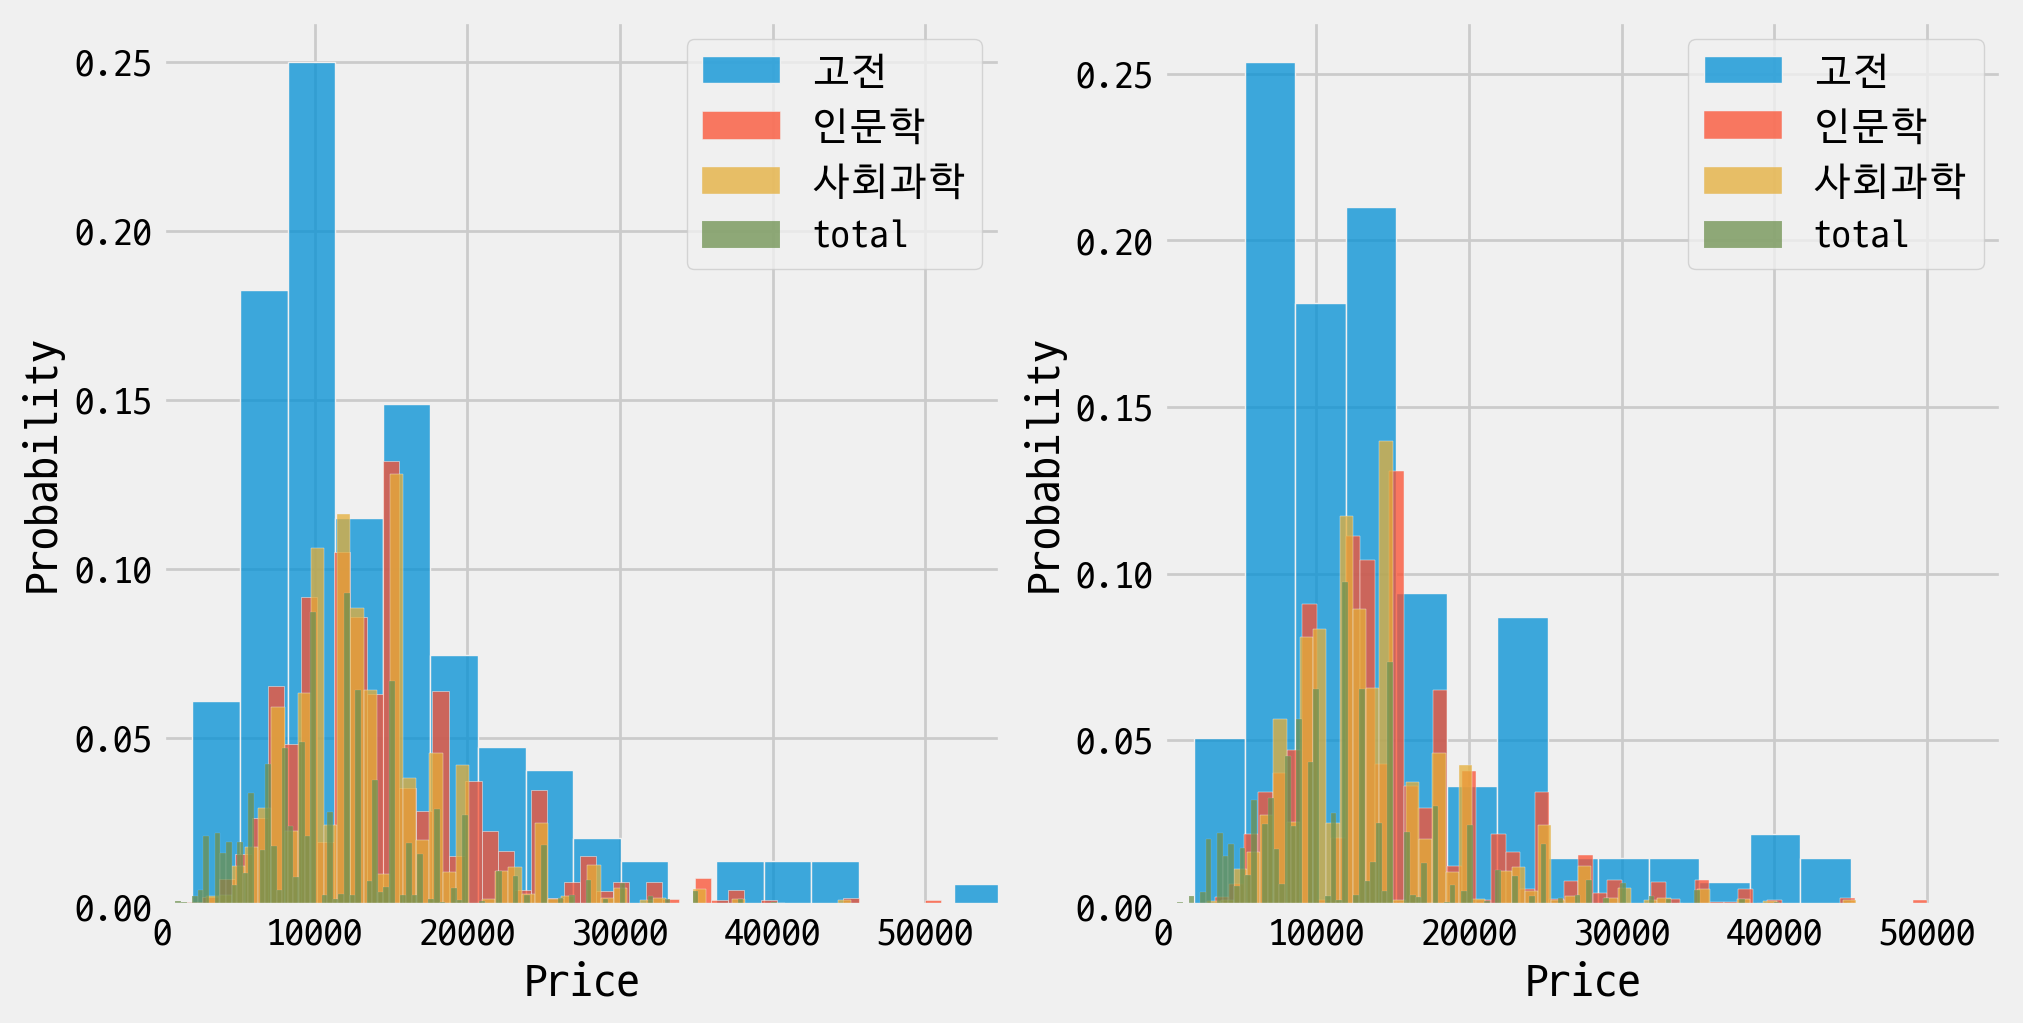

In [27]:
df_temp = bk_info.copy()
fig,ax = plt.subplots(1,2,figsize=(10,5))
df_temp = df_temp[(df_temp.year < 2014)]
sns.histplot(data=df_temp[df_temp['Category']=='고전'],x='Price',stat='probability',ax=ax[0],label='고전')
sns.histplot(data=df_temp[df_temp['Category']==
                          '인문학'],x='Price',stat='probability',ax=ax[0],label='인문학')
sns.histplot(data=df_temp[df_temp['Category']==
                          '사회과학'],x='Price',stat='probability',ax=ax[0],label='사회과학')
sns.histplot(data=df_temp,x='Price',stat='probability',ax=ax[0],label='total')
ax[0].set_xlim(0,55000) 
ax[0].legend()
df_temp = df_temp[(df_temp.year < 2014) & (df_temp.year > 1994)]
sns.histplot(data=df_temp[df_temp['Category']=='고전'],x='Price',stat='probability',ax=ax[1],label='고전')
sns.histplot(data=df_temp[df_temp['Category']==
                          '인문학'],x='Price',stat='probability',ax=ax[1],label='인문학')
sns.histplot(data=df_temp[df_temp['Category']==
                          '사회과학'],x='Price',stat='probability',ax=ax[1],label='사회과학')
sns.histplot(data=df_temp,x='Price',stat='probability',ax=ax[1],label='total')

ax[1].set_xlim(0,55000) 
ax[1].legend();

In [28]:
bk_info['year_grp'] = np.round((bk_info['year']-2000)/5)

pd.pivot_table(bk_info,'Price',index='Category',columns='year_grp',aggfunc=np.mean)

year_grp,-1.0,0.0,1.0,2.0,3.0,4.0,5.0
Category,,,,,,,
건강/취미,9025.000000,11376.666667,13643.448276,13584.650113,14388.176895,17315.354839,23302.459016
경제경영,10413.684211,12361.516035,13466.771160,15142.526837,16371.910112,17933.995037,20454.700855
고전,13070.000000,12706.451613,15743.478261,15522.222222,17500.000000,NaN,NaN
과학,11162.025316,13112.457912,16350.558659,17752.589641,18769.206349,19536.962025,22943.046358
달력/기타,20000.000000,9367.647059,9045.000000,7375.000000,10742.857143,8150.000000,NaN
대학교재/전문서적,14411.380145,17822.233400,20525.626204,22306.374502,26814.887640,27913.775510,32782.352941
만화,3528.301887,3904.175824,5113.787991,6442.906178,6754.103896,8308.950893,9425.788752
사회과학,10820.143885,11691.972789,14112.313938,15757.958288,16898.034076,17899.175127,20654.666667
소설/시/희곡,7734.193548,8780.959446,9528.979754,9887.470259,10456.965329,12773.159862,15125.700935


In [69]:
fix_cate={
    '유아' : '아동/청소년',
    '청소년' : '아동/청소년',
    '청소년_추천도서' : '아동/청소년',
    '어린이' : '아동/청소년',
    '유아' : '아동/청소년',
    '일본 도서' : '외국어',
    '고전' : '인문학'
}

filter_cate=['달력/기타']
cond = bk_info.Category.isin(fix_cate.keys())
bk_info.loc[cond,'Category'] = bk_info.loc[cond,'Category'].map(fix_cate)
cond = bk_info.Category.isin(filter_cate)
bk_info = bk_info[~cond]

In [70]:
bk_info.Price.describe()
q1, q3 = np.quantile(bk_info.Price,0.25),np.quantile(bk_info.Price,0.75)
IQR = q3-q1
q1-1.5*IQR, q3+1.5*IQR

(-5200.0, 30000.0)

In [71]:
np.mean(bk_info.Price > q3+1.5*IQR), np.mean(bk_info.Price > 40000)

(0.03464378691032122, 0.009420678896666295)

In [91]:
# q1-1.5IQR, q1, q2, q3, q3+1.5IQR, max
n_rnge = 9

price_lvl_ths = {
    key : [np.quantile(bk_info.loc[bk_info.year_grp == key,'Price'],i/n_rnge) for i in range(1,n_rnge+1)]
    for key in range(-1,6)}
for k,v in price_lvl_ths.items():
    v[-2] =np.quantile(bk_info.loc[bk_info.year_grp == k,'Price'],1-0.005) 
#price_lvl_ths[-2] = q3+1.5*IQR
bk_info['Price_lvl'] = np.zeros(len(bk_info))

print(price_lvl_ths)

for k,v in price_lvl_ths.items():
    cond_y = bk_info.year_grp == k
    for i,ths in enumerate(v[::-1]):
        cond = bk_info['Price'] <= ths
        bk_info.loc[cond & cond_y,'Price_lvl'] = len(v)-i

display(pd.crosstab(bk_info['year_grp'],bk_info['Price_lvl']))
display(pd.crosstab(bk_info['Category'],bk_info['Price_lvl']))


{-1: [3500.0, 5000.0, 6000.0, 7000.0, 8000.0, 9500.0, 12000.0, 45000.0, 165000.0], 0: [4500.0, 7000.0, 8000.0, 9000.0, 10000.0, 12000.0, 15000.0, 42000.0, 220000.0], 1: [5900.0, 8500.0, 9500.0, 10000.0, 12000.0, 13000.0, 15000.0, 45000.0, 160000.0], 2: [6000.0, 8900.0, 10800.0, 12000.0, 13000.0, 14000.0, 15000.0, 45000.0, 138000.0], 3: [5200.0, 7000.0, 9800.0, 12500.0, 13800.0, 15000.0, 16500.0, 48000.0, 180000.0], 4: [6000.0, 9800.0, 13000.0, 14800.0, 15500.0, 17000.0, 19000.0, 50000.0, 150000.0], 5: [6000.0, 12000.0, 15000.0, 16800.0, 18000.0, 19500.0, 22000.0, 55000.0, 250000.0]}


Price_lvl,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
year_grp,,,,,,,,,
-1.0,458,404,367,478,345,337,499,656,16
0.0,1642,1947,1925,1549,1667,1277,1614,2605,66
1.0,1961,2177,1743,2022,2389,951,1637,3427,72
2.0,2138,1631,1923,2771,1797,1285,1670,3656,70
3.0,2214,2512,1858,2244,2352,3125,1105,4229,95
4.0,2920,1943,2794,2299,1984,3116,1889,4402,101
5.0,887,708,564,674,1039,418,781,1270,24


Price_lvl,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
Category,,,,,,,,,
건강/취미,78,159,220,420,395,356,367,482,12
경제경영,119,139,220,614,1107,1197,1199,1370,7
과학,9,58,117,178,211,271,313,673,16
대학교재/전문서적,55,146,149,128,234,231,505,2403,125
만화,9101,2355,1006,703,438,218,133,395,7
사회과학,44,180,307,502,681,754,692,1129,11
소설/시/희곡,966,5163,4391,3011,1861,1433,702,833,18
수험서/자격증,75,288,771,453,367,485,559,3814,38
아동/청소년,22,276,494,490,398,228,135,113,0


In [92]:
temp = pd.pivot_table(bk_info[['year_grp','Price_lvl','Category']],index=['year_grp','Price_lvl'],columns='Category',aggfunc=len).fillna(0).T

In [93]:
temp.loc[:,(-1.0,slice(0,8))].apply(lambda x:np.array(x,dtype=int),axis=1)

Category
건강/취미               [5, 9, 9, 21, 5, 5, 15, 11]
경제경영              [0, 5, 7, 16, 12, 15, 19, 21]
과학                  [0, 5, 8, 10, 8, 8, 15, 25]
대학교재/전문서적     [18, 23, 21, 23, 30, 30, 88, 170]
만화                   [86, 5, 11, 0, 4, 0, 0, 0]
사회과학            [4, 11, 11, 23, 24, 19, 22, 24]
소설/시/희곡      [52, 82, 100, 125, 71, 65, 74, 51]
수험서/자격증                [0, 0, 0, 1, 0, 0, 0, 2]
아동/청소년              [3, 17, 7, 12, 13, 8, 5, 4]
에세이               [4, 20, 19, 38, 10, 12, 5, 2]
여행                     [1, 1, 1, 2, 0, 7, 4, 1]
역사               [1, 14, 7, 24, 17, 24, 32, 50]
예술/대중문화        [10, 37, 33, 28, 23, 25, 40, 51]
외국어            [17, 22, 25, 41, 26, 24, 25, 38]
요리/살림                  [1, 1, 1, 5, 1, 3, 2, 6]
인문학             [6, 25, 21, 34, 31, 31, 66, 85]
자기계발                  [0, 5, 6, 11, 5, 4, 1, 0]
종교/역학        [250, 119, 70, 50, 55, 48, 77, 86]
좋은부모                 [0, 3, 9, 14, 10, 5, 3, 6]
컴퓨터/모바일               [0, 0, 1, 0, 0, 4, 6, 23]
dtype: object

만화, 대학교재, 종교/역학

In [95]:

df = pd.DataFrame(index=bk_info.Category.unique(),columns=np.unique(bk_info.year_grp))
for col in df.columns:
    df[col]=temp.loc[:,(col,slice(0,n_rnge+1))].apply(lambda x:np.array(x,dtype=int),axis=1)

df

,-1.0,0.0,1.0,2.0,3.0,4.0,5.0
수험서/자격증,"[0, 0, 0, 1, 0, 0, 0, 2, 0]","[1, 12, 5, 8, 10, 13, 30, 164, 1]","[9, 71, 42, 26, 51, 27, 43, 332, 0]","[3, 19, 74, 46, 25, 21, 47, 354, 3]","[21, 18, 86, 173, 54, 115, 69, 1070, 15]","[39, 108, 498, 156, 155, 263, 265, 1440, 17]","[2, 60, 66, 43, 72, 46, 105, 452, 2]"
소설/시/희곡,"[52, 82, 100, 125, 71, 65, 74, 51, 0]","[21, 518, 653, 338, 169, 139, 108, 76, 0]","[285, 770, 569, 288, 289, 92, 128, 96, 2]","[491, 1025, 783, 691, 273, 185, 135, 164, 2]","[72, 1484, 1278, 805, 595, 524, 133, 238, 5]","[35, 1016, 846, 594, 317, 398, 90, 176, 6]","[10, 268, 162, 170, 147, 30, 34, 32, 3]"
인문학,"[6, 25, 21, 34, 31, 31, 66, 85, 3]","[9, 105, 88, 82, 108, 109, 140, 186, 5]","[29, 53, 59, 109, 146, 70, 151, 298, 10]","[13, 20, 47, 116, 141, 111, 168, 460, 14]","[5, 7, 26, 103, 151, 363, 118, 451, 11]","[3, 24, 99, 166, 177, 388, 200, 315, 9]","[0, 11, 22, 56, 128, 71, 81, 99, 1]"
만화,"[86, 5, 11, 0, 4, 0, 0, 0, 0]","[1162, 123, 22, 14, 19, 10, 6, 9, 0]","[1039, 144, 58, 53, 22, 10, 11, 11, 1]","[1204, 215, 107, 101, 35, 23, 25, 38, 0]","[2023, 936, 304, 276, 112, 86, 13, 99, 1]","[2725, 642, 412, 173, 218, 84, 50, 173, 3]","[862, 290, 92, 86, 28, 5, 28, 65, 2]"
경제경영,"[0, 5, 7, 16, 12, 15, 19, 21, 0]","[15, 58, 87, 127, 231, 166, 188, 154, 3]","[44, 45, 59, 173, 367, 153, 199, 233, 3]","[33, 11, 36, 202, 199, 137, 223, 370, 0]","[12, 6, 7, 19, 99, 272, 143, 242, 1]","[15, 8, 20, 50, 111, 408, 326, 271, 0]","[0, 6, 4, 27, 88, 46, 101, 79, 0]"
건강/취미,"[5, 9, 9, 21, 5, 5, 15, 11, 0]","[4, 47, 58, 62, 74, 47, 50, 46, 2]","[14, 52, 36, 62, 87, 38, 58, 82, 6]","[17, 21, 48, 97, 60, 41, 77, 81, 1]","[22, 17, 18, 98, 109, 131, 53, 105, 1]","[16, 12, 42, 62, 46, 79, 78, 130, 0]","[0, 1, 9, 18, 14, 15, 36, 27, 2]"
예술/대중문화,"[10, 37, 33, 28, 23, 25, 40, 51, 1]","[24, 86, 41, 38, 82, 58, 109, 140, 4]","[50, 54, 26, 39, 73, 33, 87, 194, 8]","[12, 16, 26, 37, 21, 22, 52, 210, 9]","[9, 4, 14, 40, 31, 71, 41, 178, 5]","[10, 17, 42, 33, 29, 107, 97, 237, 11]","[0, 9, 4, 11, 37, 15, 41, 75, 4]"
사회과학,"[4, 11, 11, 23, 24, 19, 22, 24, 1]","[4, 77, 95, 116, 127, 84, 120, 111, 1]","[21, 50, 49, 111, 145, 48, 129, 185, 1]","[7, 21, 59, 132, 123, 105, 162, 298, 4]","[5, 3, 17, 57, 77, 257, 74, 272, 1]","[3, 12, 60, 48, 119, 212, 144, 187, 3]","[0, 6, 16, 15, 66, 29, 41, 52, 0]"
종교/역학,"[250, 119, 70, 50, 55, 48, 77, 86, 0]","[290, 269, 162, 127, 155, 102, 103, 117, 6]","[303, 261, 147, 174, 161, 55, 88, 166, 2]","[239, 78, 183, 206, 82, 54, 53, 139, 1]","[7, 10, 19, 109, 52, 87, 32, 106, 9]","[22, 38, 163, 46, 71, 67, 32, 100, 8]","[9, 17, 29, 6, 26, 9, 16, 32, 2]"
자기계발,"[0, 5, 6, 11, 5, 4, 1, 0, 0]","[4, 70, 137, 108, 102, 48, 34, 11, 0]","[21, 97, 129, 293, 237, 50, 69, 45, 0]","[21, 27, 103, 312, 190, 118, 109, 87, 0]","[6, 3, 8, 78, 256, 295, 62, 71, 1]","[6, 12, 62, 189, 188, 301, 82, 50, 0]","[1, 4, 7, 53, 124, 53, 42, 4, 0]"


In [42]:
#apply tokenizer
cols_freq = ['Author','Publshr']

In [26]:
#아래 ths 는 EDA 결과 제가 자의적으로 정한 내용
bookinfo = data_dict['trn']['X']
ths_author = int(np.round(len(bookinfo)/500)*75)
ths_publshr = int(np.round(len(bookinfo)/500)*5)

map_author_encode = make_author_encode_map(bookinfo[['Author','SalesPoint']],ths_author)
map_publshr_encode = make_publshr_encode_map(bookinfo['Publshr'],ths_publshr)

encode_maps = {
    'Author' : lambda x : encode_tokens(map_author_encode,x,oov=False),
    'Publshr' : lambda x : encode_tokens(map_publshr_encode,x,oov=False),
}

In [27]:
for mode,data in data_dict.items():
    for col in tqdm(cols_freq):
        data['X'][col] = data['X'][col].map(encode_maps[col]).astype(str)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 38.50it/s]


In [28]:
data_dict['trn']['X'].head()

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
84226,2013 최신시사상식 162집,NaN,0,38,False,20130715,223,수험서/자격증
82296,엿보는 고헤이지,NaN,0,185,True,20130329,304,소설/시/희곡
120256,한국 요괴 도감,NaN,0,14,False,20190321,3564,인문학
91927,마스카 애장판 9,NaN,0,3,False,20151102,316,만화
145531,안전하고 친절한 블록체인 안내서,NaN,0,0,False,20231120,758,경제경영


In [37]:
bk_info['Author_code'] = data_dict['trn']['X']['Author']
bk_info['Publshr_code'] = data_dict['trn']['X']['Publshr']

df_temp = bk_info[bk_info['Category'] == '고전']
display(df_temp.Author_code.value_counts())
np.mean(df_temp.Author_code == '0'),np.mean(bk_info.Author_code=='0')
display(np.mean(df_temp.loc[df_temp.Author_code == '0','Price']))
display(np.mean(df_temp.loc[df_temp.Author_code != '0','Price']))
display(np.unique(df_temp.Author,return_counts=True))


Author_code
0       120
447       7
209       5
967       4
946       2
1017      2
453       2
1495      1
1195      1
1297      1
541       1
452       1
49        1
Name: count, dtype: int64

13621.666666666666

16185.714285714286

(array(['간호윤', '강신웅', '교수신문', '권영한', '귀곡자', '그림 형제', '김달진', '김담구', '김만중',
        '김봉곤', '김부식', '김성중', '김시습', '김영수', '김용택', '김원중 편저자', '김쟁원', '김풍기',
        '김화경', '남영로', '노병천', '레오 니콜라예비치 톨스토이', '마르코 폴로', '마리온 기벨', '마이클 탕',
        '모리야 히로시', '몽테뉴', '미리내공방', '민영환', '박건영.이원규', '박기봉', '박명희', '박지원',
        '반덕진', '버나드 맨더빌', '버지니아 울프', '범립본 원저', '보카치오', '북앤북 편집부', '사마천',
        '샤론 르벨', '서정기', '성백효', '성현', '소포클레스', '손종섭', '송재소', '송철규',
        '슈테판 츠바이크', '신광한', '신동흔', '신유한', '아담 스미스', '아리스토텔레스', '아리스토파네스',
        '아이스킬로스ㆍ소포클레스', '야마구치 히사카즈', '양자오', '어니스트 톰슨 시튼', '에우리피데스', '오현리',
        '유몽인', '유의경', '유향', '이강옥 엮어옮김', '이규보', '이덕무', '이병혁', '이수광', '이순신',
        '이승수', '이승수.서신혜', '이언진', '이우성', '이응백', '이익', '이인호', '이중환', '이형식',
        '이혜구', '임시종', '임형택', '장연', '전국한문교사모임', '정민', '정범진', '정약용',
        '정재서.한형조.이재민', '조경남', '조나단 스위프트', '조수삼', '조위', '죠제프 베디에', '천갑녕',
        '최근덕', '최석기', '최인욱', '최철', '추적', '한비자', '허경진', '허명규', '허성도', '허웅',
        '혜초', '호메로스', '홍경호', '홍길주', '홍대용', '홍순명',

/tmp/ipykernel_2135/2887848769.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['check'] = df_temp['Author_code']=='0'


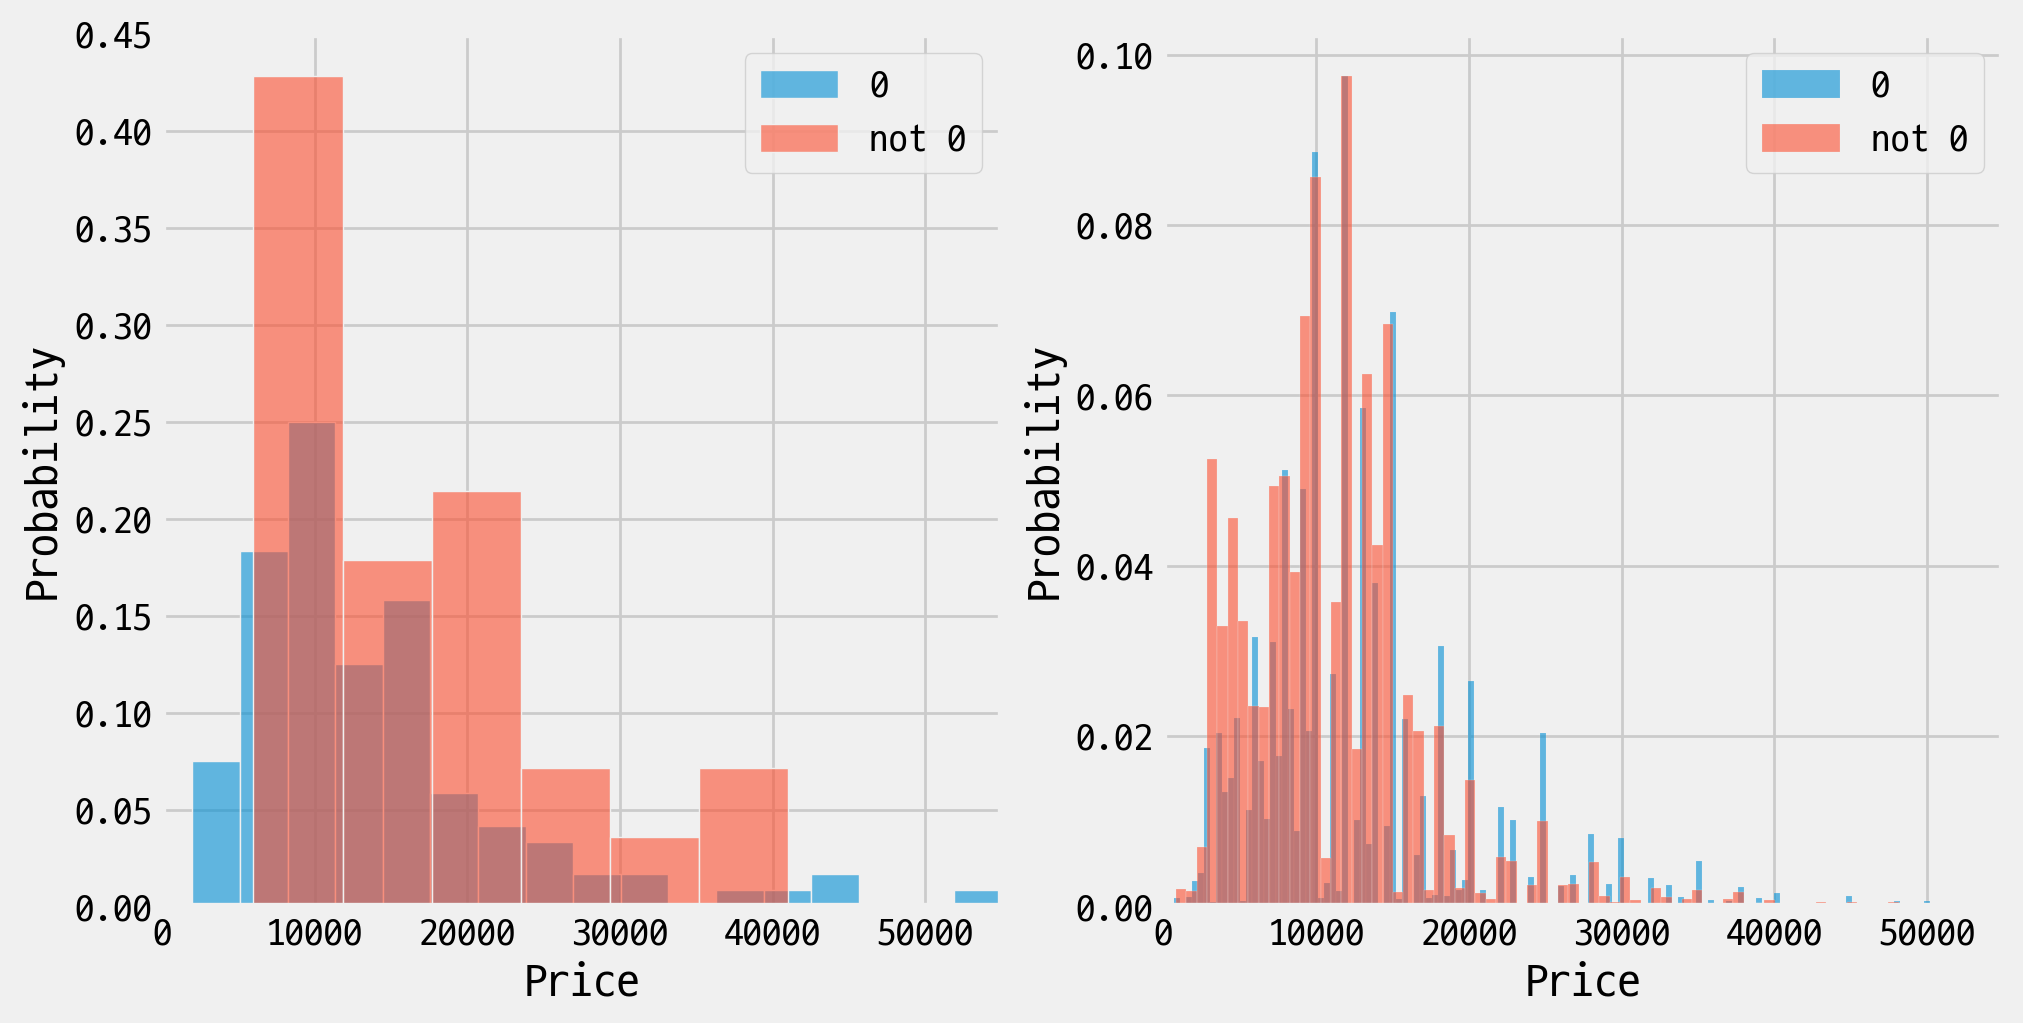

In [43]:
df_temp = bk_info[bk_info['Category'] == '고전']
df_temp['check'] = df_temp['Author_code']=='0'
fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(data=df_temp[df_temp['Author_code']=='0'],x='Price',stat='probability',ax=ax[0],label='0',alpha=0.6,multiple='dodge')
sns.histplot(data=df_temp[df_temp['Author_code']!='0'],x='Price',stat='probability',ax=ax[0],label='not 0',alpha=0.6,multiple='dodge')
ax[0].set_xlim(0,55000) 
ax[0].legend()
df_temp = bk_info[(bk_info.year < 2014) & (bk_info.year > 1994)]
sns.histplot(data=df_temp[df_temp['Author_code']=='0'],x='Price',stat='probability',ax=ax[1],label='0',alpha=0.6,multiple='dodge')
sns.histplot(data=df_temp[df_temp['Author_code']!='0'],x='Price',stat='probability',ax=ax[1],label='not 0',alpha=0.6,multiple='dodge')

ax[1].set_xlim(0,55000) 
ax[1].legend();

In [124]:
X_col_dict = {
 'BName':'제목',
 'BName_sub':'부제',
 'Category':'분류',
 'Pdate':'출간일',
 'Author':'저자 인지도 순위',
 'Author_mul':'공동 저자 유무',
 'Publshr':'출판사 인지도 순위',
}
#kor_exist={True:'있음',False:'없음'}
kor_exist={True:'참',False:'거짓'}

In [125]:
ranks = ['Author','Publshr']

#oov_val = '.'
oov_val = '순위 외'

for mode,sample in tqdm(data_dict.items()):
    for col in ranks:
        cond = data_dict[mode]['X'][col] == '0'
        data_dict[mode]['X'].loc[cond,col] = oov_val

100%|██████████| 3/3 [00:00<00:00, 99.77it/s]


In [126]:
bool_key = True 

#encode X
X_encoded=dict()
for mode,sample in tqdm(data_dict.items()):
    X_mode = sample['X'].copy()
    #padding and encoding
    encoded = pd.DataFrame(index=X_mode.index)
    X_mode['BName_sub'] = X_mode['BName_sub'].fillna('.')
    X_mode['Pdate'] = X_mode['Pdate'].astype(str).apply(lambda x :f'{x[:4]}년 {x[4:6]}월 {x[6:]}일')
    X_mode['Author_mul'] = X_mode['Author_mul'].map(kor_exist)
    for col,sub in X_col_dict.items():
        if bool_key : encoded[col] = X_mode[col].apply(lambda x: f'{sub} : {x}') 
        else : encoded[col] = X_mode[col].astype(str)
    temp = '[CLS]' + encoded[X_col_dict.keys()].agg(' [SEP] '.join, axis=1) + ' [SEP]'
    X_encoded[mode] = temp.values

100%|██████████| 3/3 [00:02<00:00,  1.40it/s]


In [127]:
data_dict['trn']['X'].iloc[74310]

BName         프러포즈는 필요없어
BName_sub            NaN
Author              순위 외
Publshr             순위 외
Author_mul          True
Pdate           20070927
SalesPoint            68
Category         소설/시/희곡
Name: 46321, dtype: object

In [128]:
X_encoded['trn'][74310]

'[CLS]제목 : 프러포즈는 필요없어 [SEP] 부제 : . [SEP] 분류 : 소설/시/희곡 [SEP] 출간일 : 2007년 09월 27일 [SEP] 저자 인지도 순위 : 순위 외 [SEP] 공동 저자 유무 : 참 [SEP] 출판사 인지도 순위 : 순위 외 [SEP]'

In [48]:
X_encoded['vld'][4310]

'[CLS]제목 : 2022 최신판 MBC 기본직무소양평가 최종모의고사 6회분 + 무료NCS특강 [SEP] 부제 : . [SEP] 분류 : 수험서/자격증 [SEP] 출간일 : 2022년 08월 25일 [SEP] 저자 인지도 순위 : 1556 [SEP] 공동 저자 유무 : 거짓 [SEP] 출판사 인지도 순위 : 21 [SEP]'

In [49]:
data_dict['trn']['X'].iloc[74310,3], '268' in data_dict['trn']['X']['Publshr'].values

('순위 외', True)

In [52]:
for mode,data in X_encoded.items():
    temp = np.array(list(map(len,data)))
    print(mode,temp.max(),temp.min())

trn 250 132
vld 257 134
tst 236 134


In [53]:
courpus_size_in = 31150
max_len = 64+len(X_col_dict)*3+1

max_len

86

In [54]:
X_coded = {
    mode : data
    for mode, data in X_encoded.items()
}
X_coded['info'] ={
    'corpus_size' : courpus_size_in,
    'max_len' : 100
}

### encode y

In [55]:
def remain_k_digits(n,k):
  r = np.floor(np.log10(n))
  temp = np.round(n/(10**r),k-1)
  temp = np.round(temp*(10**r),0)
  return (temp).astype(int)

def make_val_keys(data):
  lbnd = data.min()//1000
  ubnd = data.max()//1000
  temp = np.unique(remain_k_digits(np.arange(lbnd,ubnd+2),2)*1000)
  return temp[1:]

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0
    return map_token[x] if x in map_token else oov_val

def encode_to_2digit(data,keys):
  val = remain_k_digits(data,2)
  val[val < keys.min()] = keys.min()
  val[val > keys.max()] = keys.max()

  cond = val < 10000
  val[cond] = remain_k_digits(val[cond],1)
  encode_map= {
      k : i for i,k in enumerate(keys)
  }
  encode_1line = lambda y : list(map(lambda x : encode_tokens(encode_map,x),y))
  return np.apply_along_axis(encode_1line,0,val), encode_map


In [56]:
data = data_dict['trn']['y']
val_keys = make_val_keys(data)
encoded,encode_map = encode_to_2digit(data,val_keys)

/tmp/ipykernel_1989/3157627052.py:2: RuntimeWarning: divide by zero encountered in log10
  r = np.floor(np.log10(n))
/tmp/ipykernel_1989/3157627052.py:3: RuntimeWarning: invalid value encountered in divide
  temp = np.round(n/(10**r),k-1)
/tmp/ipykernel_1989/3157627052.py:5: RuntimeWarning: invalid value encountered in cast
  return (temp).astype(int)


In [57]:
encoded.min()

0

In [58]:
decode_map = {v:k for k,v in encode_map.items()}

In [59]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [60]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    coded,_ = encode_to_2digit(sample['y'],val_keys)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': coded, }

corpus_size_out=len(encode_map)
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'encode':{'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    },
    'corpus_size':  corpus_size_out,
}

    

In [61]:
for mode,sample in y_coded.items():
    if mode == 'info' : continue
    temp = sample['coded']
    print(mode,temp.min(),temp.max())

trn 0 114
vld 0 114
tst 0 112


### encode log y

In [50]:
# encode y

def encode_log(x):
    str_x = f'{np.log10(x):.4f}'.split('.')
    temp = [str_x[0]]+list(str_x[1])
    return ['[SOS]']+temp+['[EOS]']

tkn_lists = data_dict['trn']['y'].apply(encode_log).values
#y_tkn_vals = np.array(list(itertools.chain(*tkn_lists)))
y_tkn_vals = np.concatenate(tkn_lists,axis=0)
y_tkn_freq = np.unique(y_tkn_vals,return_counts=True)
map_y_tkns = make_encoding_by_freq(y_tkn_freq)
encode_y_1line = lambda x : list(map(lambda y : encode_tokens(map_y_tkns,y,oov=False),x))

display(y_tkn_freq)
display(map_y_tkns)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[EOS]', '[SOS]'],
       dtype='<U5'),
 array([ 55809,  66163,  46786,  69609, 109232,  28181,  23211,  43861,
         16278,  46735, 101173, 101173]))

{'4': 1,
 '[EOS]': 2,
 '[SOS]': 3,
 '3': 4,
 '1': 5,
 '0': 6,
 '2': 7,
 '9': 8,
 '7': 9,
 '5': 10,
 '6': 11,
 '8': 12,
 '[PAD]': 0}

In [52]:
decode_map = {v:k for k,v in map_y_tkns.items()}
sen_tkns = ['[SOS]','[EOS]','[PAD]',]
sentkns_dict = {
    tkn : map_y_tkns[tkn]
    for tkn in sen_tkns
}

In [53]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [55]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    temp = sample['y'].apply(encode_log)
    padded = pad_sequences(temp,padding='post',
                                   maxlen=y_max_len,
                                   value='[PAD]',dtype=object)
    intrmd = np.apply_along_axis(encode_y_1line,0,padded)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': intrmd.astype(np.int32), }

corpus_size_out=13
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    'corpus_size':  corpus_size_out,
    'tkn': sentkns_dict ,
    'max_len': y_max_len,
}

    

In [42]:
decode_map

{0: 1000,
 1: 2000,
 2: 3000,
 3: 4000,
 4: 5000,
 5: 6000,
 6: 7000,
 7: 8000,
 8: 9000,
 9: 10000,
 10: 11000,
 11: 12000,
 12: 13000,
 13: 14000,
 14: 15000,
 15: 16000,
 16: 17000,
 17: 18000,
 18: 19000,
 19: 20000,
 20: 21000,
 21: 22000,
 22: 23000,
 23: 24000,
 24: 25000,
 25: 26000,
 26: 27000,
 27: 28000,
 28: 29000,
 29: 30000,
 30: 31000,
 31: 32000,
 32: 33000,
 33: 34000,
 34: 35000,
 35: 36000,
 36: 37000,
 37: 38000,
 38: 39000,
 39: 40000,
 40: 41000,
 41: 42000,
 42: 43000,
 43: 44000,
 44: 45000,
 45: 46000,
 46: 47000,
 47: 48000,
 48: 49000,
 49: 50000,
 50: 51000,
 51: 52000,
 52: 53000,
 53: 54000,
 54: 55000,
 55: 56000,
 56: 57000,
 57: 58000,
 58: 59000,
 59: 60000,
 60: 61000,
 61: 62000,
 62: 63000,
 63: 64000,
 64: 65000,
 65: 66000,
 66: 67000,
 67: 68000,
 68: 69000,
 69: 70000,
 70: 71000,
 71: 72000,
 72: 73000,
 73: 74000,
 74: 75000,
 75: 76000,
 76: 77000,
 77: 78000,
 78: 79000,
 79: 80000,
 80: 81000,
 81: 82000,
 82: 83000,
 83: 84000,
 84: 85000,

In [62]:
RSLT_DIR

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/'

In [64]:
ls {RSLT_DIR}/model_input

537.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


BERT_cls-single.v1.0_st-0_X_info.pkl   encodedXy.v2.5_st-0_X_tst.pkl
BERT_cls-single.v1.0_st-0_X_trn.pkl    encodedXy.v2.5_st-0_X_vld.pkl
BERT_cls-single.v1.0_st-0_X_tst.pkl    encodedXy.v2.5_st-0_y_info.pkl
BERT_cls-single.v1.0_st-0_X_vld.pkl    encodedXy.v2.5_st-0_y_trn.pkl
BERT_cls-single.v1.0_st-0_y_info.pkl   encodedXy.v2.5_st-0_y_tst.pkl
BERT_cls-single.v1.0_st-0_y_trn.pkl    encodedXy.v2.5_st-0_y_vld.pkl
BERT_cls-single.v1.0_st-0_y_tst.pkl    encodedXy.v3.0_st-0_X_info.pkl
BERT_cls-single.v1.0_st-0_y_vld.pkl    encodedXy.v3.0_st-0_X_trn.pkl
BERT_cls-single.v1.a_st-0_X_info.pkl   encodedXy.v3.0_st-0_X_tst.pkl
BERT_cls-single.v1.a_st-0_X_trn.pkl    encodedXy.v3.0_st-0_X_vld.pkl
BERT_cls-single.v1.a_st-0_X_tst.pkl    encodedXy.v3.0_st-0_y_info.pkl
BERT_cls-single.v1.a_st-0_X_vld.pkl    encodedXy.v3.0_st-0_y_trn.pkl
BERT_cls-single.v1.a_st-0_y_info.pkl   encodedXy.v3.0_st-0_y_tst.pkl
BERT_cls-single.v1.a_st-0_y_trn.pkl    encodedXy.v3.0_st-0_y_vld.pkl
BERT_cls-single.v1.a_st-0_y_tst

In [65]:
data_type = 'BERT_cls-single'
strat=0
ver='1.5'
dir_path = os.path.join(RSLT_DIR,'model_input')
for mode, x_scaled in X_coded.items():
    save_pkl(dir_path,'{}.v{}_st-{}_X_{}.pkl'.format(data_type,ver,strat,mode),x_scaled)
for mode,data in y_coded.items(): 
    save_pkl(dir_path,'{}.v{}_st-{}_y_{}.pkl'.format(data_type,ver,strat,mode),data)

In [66]:
cand = list(filter(lambda x : 'info' in x ,os.listdir(dir_path)))
cand = sorted(cand)

temp = list(map(lambda x: load_pkl(os.path.join(dir_path,x)),cand))
[(n,x.keys()) for n,x in zip(cand,temp)]

[('BERT_cls-single.v1.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.5_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.5_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.a_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.a_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('encodedXy-single.v5.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len', 'encode'])),
 ('encodedXy-single.v5.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size', 'tkn', 'max_len'])),
 ('encodedXy.v2.0_st-0_y_info.pkl', dict_keys(['decode_map', 'freq'])),
 ('encodedXy.v2.5_st-0_X_info.pkl', dict_keys(['corpus_size'])),
 ('encodedXy.v2.5_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'freq', 'tkn', 'max_len'])),
 ('encodedXy.v3.0_st-0_X_info.pkl', dict_keys(['corpus_siz

#### numpy,torch examples

In [164]:
np.triu(np.ones((1,7,7)),k=1)==0

array([[[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]]])

In [58]:
import torch
torch.zeros(3,3,3)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [166]:
a = np.triu(np.ones((2,7,3)),k=-1)


a = torch.LongTensor(a)
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]])

In [167]:
a[:,-1,:] = 2

a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]]])

In [175]:
a[:,-2,:] = torch.LongTensor([[1,3,2],[9,8,7]])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [177]:
a[:,-3] = torch.LongTensor([5,7,8])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [178]:
a.max(dim=-1)

torch.return_types.max(
values=tensor([[1, 1, 1, 1, 8, 3, 2],
        [1, 1, 1, 1, 8, 9, 2]]),
indices=tensor([[0, 0, 1, 2, 2, 1, 0],
        [0, 0, 1, 2, 2, 0, 0]]))

In [180]:
a[:,:,-2] = torch.LongTensor([2,5,6,3,1,9,6])
a

tensor([[[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [1, 9, 2],
         [2, 6, 2]],

        [[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [9, 9, 7],
         [2, 6, 2]]])

In [183]:
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6, 10]]])

In [186]:
a[-1,-1,-1] = 7
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6,  7]]])

In [187]:
a[:,-1,:].max(dim=-1)

torch.return_types.max(
values=tensor([10,  7]),
indices=tensor([2, 2]))